<a href="https://colab.research.google.com/github/jieun0441/DataScience/blob/master/Code_S14_for_Land_Tax_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initial Path Analysis (preliminary)

In [ ]:
!apt-get -qq install graphviz
!pip install -q semopy

import pandas as pd
import numpy as np
import graphviz
from scipy.stats import zscore
from semopy import Model
import semopy.plot as semplot
from IPython.display import Image, display
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 변수명 공백 제거 (오류 방지)
df.columns = df.columns.str.strip()

# 2. 1인당 GRDP 산출 (단위: yuan/person)
df['per_capita_GRDP'] = df['GDP (10,000 yuan)'] / df['Population (10000 persons)']

# 3. 주요 변수 로그 변환 (0값 보존을 위해 np.log1p 적용)
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])
df['log_per_capita_GRDP'] = np.log1p(df['per_capita_GRDP'])

# 매개변수 로그 변환
df['log_rail_betw'] = np.log1p(df['rail_node_betweenness_weighted'])
df['log_hw_betw'] = np.log1p(df['hw_node_betweenness_weighted'])
df['log_green_rate'] = np.log1p(df['Green coverage rate of built-up area (%)'])
df['log_park_area'] = np.log1p(df['Park green space area (in hectares)'])
df['log_doctors'] = np.log1p(df['Number of doctors (people)'])
df['log_sci_exp'] = np.log1p(df['Science expenditure (in ten thousand yuan)'])
df['log_edu_exp'] = np.log1p(df['Education expenditure (in ten thousand yuan)'])

# 4. 분석용 데이터셋 결측치 제거
core_vars = [
    'log_pop', 'log_TLV', 'log_per_capita_GRDP',
    'log_rail_betw', 'log_hw_betw', 'log_green_rate', 'log_park_area',
    'log_doctors', 'log_sci_exp', 'log_edu_exp'
]
df_clean = df[core_vars].dropna().copy()

# 5. 통합 지표 생성 (결측치 제거 후 Z-score 산출)
df_clean['z_rail'] = zscore(df_clean['log_rail_betw'])
df_clean['z_hw'] = zscore(df_clean['log_hw_betw'])
df_clean['log_network_centrality'] = (df_clean['z_rail'] + df_clean['z_hw']) / 2

df_clean['z_green_rate'] = zscore(df_clean['log_green_rate'])
df_clean['z_park_area'] = zscore(df_clean['log_park_area'])
df_clean['log_park_infra'] = (df_clean['z_green_rate'] + df_clean['z_park_area']) / 2

print(f"전처리 완료. 최종 분석 데이터 개수: {len(df_clean)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 8.5 MB/s eta 0:00:00
Mounted at /content/drive
전처리 완료. 최종 분석 데이터 개수: 1378



=== Model 1 Results ===


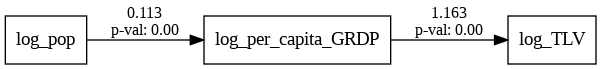


=== Model 2 Results ===


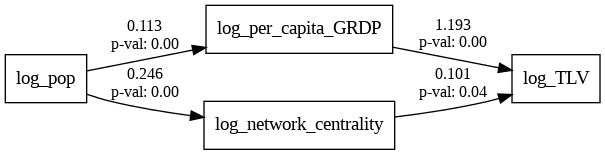


=== Model 3 Results ===


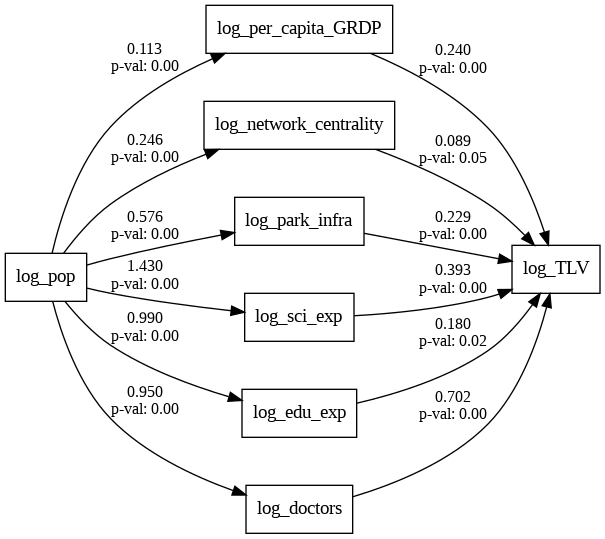

In [ ]:
# 공통 시각화 처리 함수 (직접 경로 숨김 및 좌우 정렬 적용)
def format_sem_plot(model, filename, order_vars=None):
    g = semplot.semplot(model, f"{filename}_temp.png")
    g.graph_attr['rankdir'] = 'LR'

    dot_source = g.source
    new_lines = []
    for line in dot_source.split('\n'):
        if 'log_pop' in line and 'log_TLV' in line and '->' in line:
            continue
        new_lines.append(line)

    new_dot_source = '\n'.join(new_lines)

    if order_vars:
        order_str = " -> ".join(order_vars)
        order_constraint = f"{{rank=same; {order_str} [style=invis];}}"
        new_dot_source = new_dot_source.replace('}', f'  {order_constraint}\n}}')

    g_new = graphviz.Source(new_dot_source)
    g_new.render(filename, format="png", cleanup=True)
    display(Image(f"{filename}.png"))

# ==========================================
# Model 1
# ==========================================
desc1 = """
log_per_capita_GRDP ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP
"""
model1 = Model(desc1)
model1.fit(df_clean)
res1 = model1.inspect()
print("\n=== Model 1 Results ===")
format_sem_plot(model1, "model1_LR_per_capita")

# ==========================================
# Model 2
# ==========================================
desc2 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality
"""
model2 = Model(desc2)
model2.fit(df_clean)
res2 = model2.inspect()
print("\n=== Model 2 Results ===")
order2 = ["log_per_capita_GRDP", "log_network_centrality"]
format_sem_plot(model2, "model2_LR_per_capita", order2)

# ==========================================
# Model 3
# ==========================================
desc3 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_park_infra ~ log_pop
log_sci_exp ~ log_pop
log_edu_exp ~ log_pop
log_doctors ~ log_pop

log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality + log_park_infra + log_sci_exp + log_edu_exp + log_doctors
"""
model3 = Model(desc3)
model3.fit(df_clean)
res3 = model3.inspect()
print("\n=== Model 3 Results ===")
order3 = ["log_per_capita_GRDP", "log_network_centrality", "log_park_infra", "log_sci_exp", "log_edu_exp", "log_doctors"]
format_sem_plot(model3, "model3_LR_per_capita", order3)

In [ ]:
# 결과표를 하나의 Excel 파일 내 여러 시트로 저장
output_filename = '/content/drive/MyDrive/George Land Tax/path_analysis_results.xlsx'

with pd.ExcelWriter(output_filename) as writer:
    res1.to_excel(writer, sheet_name='Model 1', index=False)
    res2.to_excel(writer, sheet_name='Model 2', index=False)
    res3.to_excel(writer, sheet_name='Model 3', index=False)

print(f"분석 결과 추출 완료: {output_filename}")

분석 결과 추출 완료: /content/drive/MyDrive/George Land Tax/path_analysis_results.xlsx


log_GRDP

In [ ]:
!apt-get -qq install graphviz
!pip install -q semopy

import pandas as pd
import numpy as np
import graphviz
from scipy.stats import zscore
from semopy import Model
import semopy.plot as semplot
from IPython.display import Image, display
from google.colab import drive

# 1. 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.columns = df.columns.str.strip()

# 2. 주요 변수 로그 변환 (np.log1p 사용)
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])
df['log_GRDP'] = np.log1p(df['GDP (10,000 yuan)']) # log_GRDP 사용

# 매개변수 로그 변환
df['log_rail_betw'] = np.log1p(df['rail_node_betweenness_weighted'])
df['log_hw_betw'] = np.log1p(df['hw_node_betweenness_weighted'])
df['log_green_rate'] = np.log1p(df['Green coverage rate of built-up area (%)'])
df['log_park_area'] = np.log1p(df['Park green space area (in hectares)'])
df['log_doctors'] = np.log1p(df['Number of doctors (people)'])
df['log_sci_exp'] = np.log1p(df['Science expenditure (in ten thousand yuan)'])
df['log_edu_exp'] = np.log1p(df['Education expenditure (in ten thousand yuan)'])

# 3. 분석용 데이터셋 결측치 제거 (지역 더미 제외)
core_vars = [
    'log_pop', 'log_TLV', 'log_GRDP',
    'log_rail_betw', 'log_hw_betw', 'log_green_rate', 'log_park_area',
    'log_doctors', 'log_sci_exp', 'log_edu_exp'
]
df_clean = df[core_vars].dropna().copy()

# 4. 통합 지표 생성
df_clean['z_rail'] = zscore(df_clean['log_rail_betw'])
df_clean['z_hw'] = zscore(df_clean['log_hw_betw'])
df_clean['log_network_centrality'] = (df_clean['z_rail'] + df_clean['z_hw']) / 2

df_clean['z_green_rate'] = zscore(df_clean['log_green_rate'])
df_clean['z_park_area'] = zscore(df_clean['log_park_area'])
df_clean['log_park_infra'] = (df_clean['z_green_rate'] + df_clean['z_park_area']) / 2

print(f"전처리 완료. 분석 데이터 개수: {len(df_clean)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전처리 완료. 분석 데이터 개수: 1378



=== Model 1 Results (log_GRDP) ===


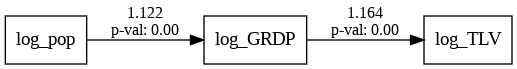


=== Model 2 Results (log_GRDP) ===


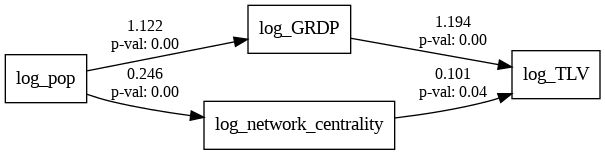


=== Model 3 Results (log_GRDP) ===


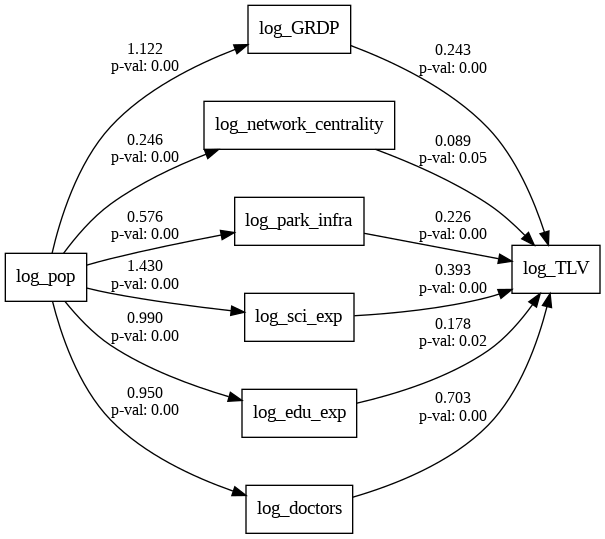

In [ ]:
# 시각화 처리 함수 (직접 경로 숨김 및 좌우 정렬)
def format_sem_plot(model, filename, order_vars=None):
    g = semplot.semplot(model, f"{filename}_temp.png")
    g.graph_attr['rankdir'] = 'LR'

    dot_source = g.source
    new_lines = []
    for line in dot_source.split('\n'):
        if 'log_pop' in line and 'log_TLV' in line and '->' in line:
            continue
        new_lines.append(line)

    new_dot_source = '\n'.join(new_lines)

    if order_vars:
        order_str = " -> ".join(order_vars)
        order_constraint = f"{{rank=same; {order_str} [style=invis];}}"
        new_dot_source = new_dot_source.replace('}', f'  {order_constraint}\n}}')

    g_new = graphviz.Source(new_dot_source)
    g_new.render(filename, format="png", cleanup=True)
    display(Image(f"{filename}.png"))

# ==========================================
# Model 1: log_GRDP 매개 효과
# ==========================================
desc1 = """
log_GRDP ~ log_pop
log_TLV ~ log_pop + log_GRDP
"""
model1 = Model(desc1)
model1.fit(df_clean)
res1 = model1.inspect()
print("\n=== Model 1 Results (log_GRDP) ===")
format_sem_plot(model1, "model1_LR_GRDP")

# ==========================================
# Model 2: log_network_centrality 추가
# ==========================================
desc2 = """
log_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_TLV ~ log_pop + log_GRDP + log_network_centrality
"""
model2 = Model(desc2)
model2.fit(df_clean)
res2 = model2.inspect()
print("\n=== Model 2 Results (log_GRDP) ===")
order2 = ["log_GRDP", "log_network_centrality"]
format_sem_plot(model2, "model2_LR_GRDP", order2)

# ==========================================
# Model 3: 전체 매개변수 포함
# ==========================================
desc3 = """
log_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_park_infra ~ log_pop
log_sci_exp ~ log_pop
log_edu_exp ~ log_pop
log_doctors ~ log_pop

log_TLV ~ log_pop + log_GRDP + log_network_centrality + log_park_infra + log_sci_exp + log_edu_exp + log_doctors
"""
model3 = Model(desc3)
model3.fit(df_clean)
res3 = model3.inspect()
print("\n=== Model 3 Results (log_GRDP) ===")
order3 = ["log_GRDP", "log_network_centrality", "log_park_infra", "log_sci_exp", "log_edu_exp", "log_doctors"]
format_sem_plot(model3, "model3_LR_GRDP", order3)

In [ ]:
output_filename = 'path_analysis_results_GRDP.xlsx'

with pd.ExcelWriter(output_filename) as writer:
    res1.to_excel(writer, sheet_name='Model 1', index=False)
    res2.to_excel(writer, sheet_name='Model 2', index=False)
    res3.to_excel(writer, sheet_name='Model 3', index=False)

print(f"분석 결과 추출 완료: {output_filename}")

분석 결과 추출 완료: path_analysis_results_GRDP.xlsx


만약 economic region dummy들을 넣는다면?

In [ ]:
!apt-get -qq install graphviz
!pip install -q semopy

import pandas as pd
import numpy as np
import graphviz
from scipy.stats import zscore
from semopy import Model
import semopy.plot as semplot
from IPython.display import Image, display
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.columns = df.columns.str.strip()

# 2. 1인당 GRDP 및 로그 변환
df['per_capita_GRDP'] = df['GDP (10,000 yuan)'] / df['Population (10000 persons)']
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])
df['log_per_capita_GRDP'] = np.log1p(df['per_capita_GRDP'])

df['log_rail_betw'] = np.log1p(df['rail_node_betweenness_weighted'])
df['log_hw_betw'] = np.log1p(df['hw_node_betweenness_weighted'])
df['log_green_rate'] = np.log1p(df['Green coverage rate of built-up area (%)'])
df['log_park_area'] = np.log1p(df['Park green space area (in hectares)'])
df['log_doctors'] = np.log1p(df['Number of doctors (people)'])
df['log_sci_exp'] = np.log1p(df['Science expenditure (in ten thousand yuan)'])
df['log_edu_exp'] = np.log1p(df['Education expenditure (in ten thousand yuan)'])

# 3. 지역 더미 변수 생성
df['Economic region'] = df['Economic region'].astype(str).str.strip()
df = pd.get_dummies(df, columns=['Economic region'], prefix='reg', dtype=float)
df.columns = df.columns.str.strip()
region_dummies = [col for col in df.columns if col.startswith('reg_')]

# 4. 분석용 데이터셋 결측치 제거
core_vars = [
    'log_pop', 'log_TLV', 'log_per_capita_GRDP',
    'log_rail_betw', 'log_hw_betw', 'log_green_rate', 'log_park_area',
    'log_doctors', 'log_sci_exp', 'log_edu_exp'
]
final_vars = core_vars + region_dummies
df_clean = df[final_vars].dropna().copy()

# 5. 통합 지표 생성
df_clean['z_rail'] = zscore(df_clean['log_rail_betw'])
df_clean['z_hw'] = zscore(df_clean['log_hw_betw'])
df_clean['log_network_centrality'] = (df_clean['z_rail'] + df_clean['z_hw']) / 2

df_clean['z_green_rate'] = zscore(df_clean['log_green_rate'])
df_clean['z_park_area'] = zscore(df_clean['log_park_area'])
df_clean['log_park_infra'] = (df_clean['z_green_rate'] + df_clean['z_park_area']) / 2

print(f"전처리 완료. 최종 분석 데이터 개수: {len(df_clean)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전처리 완료. 최종 분석 데이터 개수: 1378



=== Model 1 Results ===


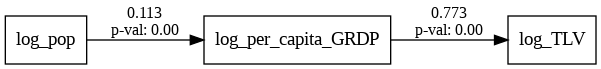


=== Model 2 Results ===


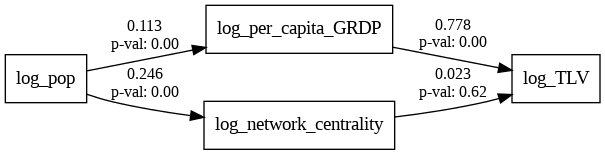


=== Model 3 Results ===


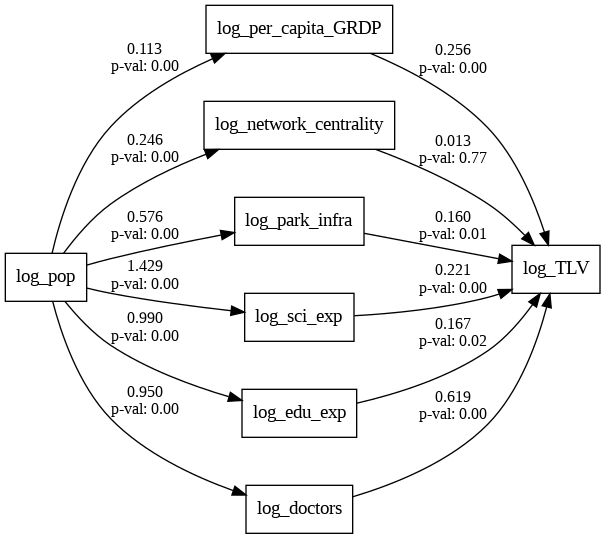

In [ ]:
# 다중공선성 방지를 위해 마지막 기준 범주 제외
if len(region_dummies) > 1:
    reg_controls = " + ".join(region_dummies[:-1])
else:
    reg_controls = region_dummies[0] if region_dummies else "0"

# 시각화 처리 함수 (통제 변수 및 직접 경로 숨김)
def format_sem_plot(model, filename, order_vars=None):
    g = semplot.semplot(model, f"{filename}_temp.png")
    g.graph_attr['rankdir'] = 'LR'

    dot_source = g.source
    new_lines = []
    for line in dot_source.split('\n'):
        # 직접 경로(log_pop -> log_TLV) 숨김
        if 'log_pop' in line and 'log_TLV' in line and '->' in line:
            continue
        # 지역 통제 변수(reg_) 관련 노드 및 화살표 숨김
        if 'reg_' in line:
            continue
        new_lines.append(line)

    new_dot_source = '\n'.join(new_lines)

    if order_vars:
        order_str = " -> ".join(order_vars)
        order_constraint = f"{{rank=same; {order_str} [style=invis];}}"
        new_dot_source = new_dot_source.replace('}', f'  {order_constraint}\n}}')

    g_new = graphviz.Source(new_dot_source)
    g_new.render(filename, format="png", cleanup=True)
    display(Image(f"{filename}.png"))

# ==========================================
# Model 1
# ==========================================
desc1 = f"""
log_per_capita_GRDP ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP + {reg_controls}
"""
model1 = Model(desc1)
model1.fit(df_clean)
res1 = model1.inspect()
print("\n=== Model 1 Results ===")
format_sem_plot(model1, "model1_LR_per_capita")

# ==========================================
# Model 2
# ==========================================
desc2 = f"""
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality + {reg_controls}
"""
model2 = Model(desc2)
model2.fit(df_clean)
res2 = model2.inspect()
print("\n=== Model 2 Results ===")
order2 = ["log_per_capita_GRDP", "log_network_centrality"]
format_sem_plot(model2, "model2_LR_per_capita", order2)

# ==========================================
# Model 3
# ==========================================
desc3 = f"""
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_park_infra ~ log_pop
log_sci_exp ~ log_pop
log_edu_exp ~ log_pop
log_doctors ~ log_pop

log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality + log_park_infra + log_sci_exp + log_edu_exp + log_doctors + {reg_controls}
"""
model3 = Model(desc3)
model3.fit(df_clean)
res3 = model3.inspect()
print("\n=== Model 3 Results ===")
order3 = ["log_per_capita_GRDP", "log_network_centrality", "log_park_infra", "log_sci_exp", "log_edu_exp", "log_doctors"]
format_sem_plot(model3, "model3_LR_per_capita", order3)

# MVR

In [2]:
#@title option 1 (without economic region dummy)
!pip install -q python-docx

import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from docx import Document
from google.colab import drive

# 1. Colab 드라이브 마운트
drive.mount('/content/drive')

# =============================================================================
# Configuration
# =============================================================================
FILE_PATH   = "/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx"
EXPORT_ROOT = "/content/drive/MyDrive/George Land Tax"

YEAR_COL    = "Year"
DEP_COL     = "Observed TLV (10000 yuan)"
LOG_Y_MODE  = "log1p"
LOG_X_MODE  = "log1p"

ROBUST_SE   = True
USE_COMMON_SAMPLE = False
TREAT_WEIGHTED_AS_ALREADY_LOGGED = True
INCLUDE_ECONOMIC_REGION = False

# =============================================================================
# Raw variable names
# =============================================================================
POP_COL   = "Population (10000 persons)"
GDP_COL   = "GDP (10,000 yuan)"
PCGDP_COL = "Per Capita GDP (10,000 yuan)"
RAIL_BETW_COL = "Train_Betweenness_weighted"
HW_BETW_COL   = "Highway_Betweenness_weighted"
GREEN_RATE_COL = "Green coverage rate of built-up area (%)"
PARK_AREA_COL  = "Park green space area (in hectares)"

NETWORK_CENT_COL = "log_network_centrality"
PARK_INFRA_COL   = "log_park_infrastructure"
LOCAL_GOV_EXP_COL = "log_local_gov_exp"

DOCTORS_COL = "Number of doctors (people)"
BUSES_COL   = "Number of operating public buses at year-end (vehicles)"
SCI_COL     = "Science expenditure (in ten thousand yuan)"
EDU_COL     = "Education expenditure (in ten thousand yuan)"

def safe_name(s: str) -> str:
    return s.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_").replace("\\", "_").replace("%", "pct").replace(",", "").replace(":", "_").replace("__", "_")

def coerce_numeric_inplace(df_: pd.DataFrame, cols):
    for c in cols:
        if c not in df_.columns: continue
        s = df_[c].astype(str).str.replace(",", "", regex=False).str.replace(" ", "", regex=False).str.replace("%", "", regex=False).str.replace("—", "", regex=False).str.replace("–", "", regex=False).str.replace("nan", "", regex=False).str.replace("None", "", regex=False)
        df_[c] = pd.to_numeric(s, errors="coerce")

def log_transform(series: pd.Series, mode: str):
    x = pd.to_numeric(series, errors="coerce")
    return np.log1p(x) if mode == "log1p" else np.where(x > 0, np.log(x), np.nan)

def map_log_name(col: str) -> str:
    return "log_" + col.replace("_weighted", "") if col.endswith("_weighted") else "log_" + col

def zscore(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    std_ = x.std(skipna=True, ddof=0)
    return pd.Series(np.nan, index=x.index) if pd.isna(std_) or std_ == 0 else (x - x.mean(skipna=True)) / std_

def standardize_var_details_columns(var_details: pd.DataFrame) -> pd.DataFrame:
    temp = var_details.copy()
    rename_map = {}
    for c in temp.columns:
        c_str = str(c).strip()
        if c_str in ["Coef.", "Coef", "coef"]: rename_map[c] = "coef"
        elif c_str in ["Std.Err.", "Std.Err", "Std. Err.", "std err"]: rename_map[c] = "se"
        elif "P>|" in c_str: rename_map[c] = "p"
        elif c_str in ["[0.025", "[0.0250", "0.025"]: rename_map[c] = "ci_low"
        elif c_str in ["0.975]", "0.9750]", "0.975"]: rename_map[c] = "ci_high"
    return temp.rename(columns=rename_map)

def build_clean_summary_table(long_df, model_order):
    out_list = []
    for year in sorted(long_df["Year"].dropna().unique().tolist()):
        df_y = long_df[long_df["Year"] == year].copy()
        terms = sorted(df_y["term"].dropna().unique().tolist())
        rows = []
        for t in terms:
            row = {"Year": year, "term": t}
            for m in model_order:
                sub = df_y[(df_y["model"] == m) & (df_y["term"] == t)]
                row.update({f"{m}_coef": sub["coef"].iloc[0] if not sub.empty else np.nan, f"{m}_se": sub["se"].iloc[0] if not sub.empty else np.nan, f"{m}_p": sub["p"].iloc[0] if not sub.empty else np.nan})
            rows.append(row)
        for stat in ["N", "R2", "AdjR2"]:
            row = {"Year": year, "term": stat}
            for m in model_order:
                sub = df_y[df_y["model"] == m]
                row.update({f"{m}_coef": sub[stat].iloc[0] if not sub.empty else np.nan, f"{m}_se": np.nan, f"{m}_p": np.nan})
            rows.append(row)
        out_list.append(pd.DataFrame(rows))
    return pd.concat(out_list, ignore_index=True) if out_list else pd.DataFrame()

def make_plot_ready_df(results_long, exclude_region=True):
    plot_df = results_long[results_long["term"] != "const"].copy()
    if exclude_region: plot_df = plot_df[~plot_df["term"].str.startswith("region_", na=False)].copy()
    plot_df["ci_low"] = plot_df["coef"] - 1.96 * plot_df["se"]
    plot_df["ci_high"] = plot_df["coef"] + 1.96 * plot_df["se"]
    return plot_df

# =============================================================================
# Load & Process Data
# =============================================================================
df = pd.read_excel(FILE_PATH)
df.columns = df.columns.str.strip()

rename_dict = {
    "Tertiary industry employment share / from 2015 onward is [urban unit employed persons] (%)": "Tertiary industry employment share (%)",
    "Secondary industry employment share / from 2015 onward is [urban unit employed persons] (%)": "Secondary industry employment share (%)",
}
df.rename(columns=rename_dict, inplace=True)

net_rename = {
    "rail_node_closeness_weighted_dist": "Train_Closeness_weighted",
    "rail_node_betweenness_weighted":    "Train_Betweenness_weighted",
    "hw_node_closeness_weighted_dist":   "Highway_Closeness_weighted",
    "hw_node_betweenness_weighted":      "Highway_Betweenness_weighted",
}
df.rename(columns={k: v for k, v in net_rename.items() if k in df.columns}, inplace=True)

raw_needed_cols = [
    YEAR_COL, DEP_COL, POP_COL, GDP_COL, "Economic region",
    RAIL_BETW_COL, HW_BETW_COL, GREEN_RATE_COL, PARK_AREA_COL,
    DOCTORS_COL, BUSES_COL, SCI_COL, EDU_COL,
]

numeric_cols = [c for c in raw_needed_cols if c not in [YEAR_COL, "Economic region"]]
coerce_numeric_inplace(df, numeric_cols)

if PCGDP_COL not in df.columns:
    df[PCGDP_COL] = np.where(pd.to_numeric(df[POP_COL], errors="coerce") > 0, (pd.to_numeric(df[GDP_COL], errors="coerce") / pd.to_numeric(df[POP_COL], errors="coerce")) / 10000.0, np.nan)

df[map_log_name(POP_COL)]   = log_transform(df[POP_COL], LOG_X_MODE)
df[map_log_name(PCGDP_COL)] = log_transform(df[PCGDP_COL], LOG_X_MODE)

if TREAT_WEIGHTED_AS_ALREADY_LOGGED:
    df[map_log_name(RAIL_BETW_COL)] = pd.to_numeric(df[RAIL_BETW_COL], errors="coerce")
    df[map_log_name(HW_BETW_COL)]   = pd.to_numeric(df[HW_BETW_COL], errors="coerce")
else:
    df[map_log_name(RAIL_BETW_COL)] = log_transform(df[RAIL_BETW_COL], LOG_X_MODE)
    df[map_log_name(HW_BETW_COL)]   = log_transform(df[HW_BETW_COL], LOG_X_MODE)

df[map_log_name(GREEN_RATE_COL)] = log_transform(df[GREEN_RATE_COL], LOG_X_MODE)
df[map_log_name(PARK_AREA_COL)]  = log_transform(df[PARK_AREA_COL], LOG_X_MODE)

for col in [DOCTORS_COL, BUSES_COL, SCI_COL, EDU_COL]:
    df[map_log_name(col)] = log_transform(df[col], LOG_X_MODE)

df["z_rail"] = zscore(df[map_log_name(RAIL_BETW_COL)])
df["z_hw"]   = zscore(df[map_log_name(HW_BETW_COL)])
df[NETWORK_CENT_COL] = (df["z_rail"] + df["z_hw"]) / 2

df["z_green_rate"] = zscore(df[map_log_name(GREEN_RATE_COL)])
df["z_park_area"]  = zscore(df[map_log_name(PARK_AREA_COL)])
df[PARK_INFRA_COL] = (df["z_green_rate"] + df["z_park_area"]) / 2

df["z_park_infra"] = zscore(df[PARK_INFRA_COL])
df["z_sci"] = zscore(df[map_log_name(SCI_COL)])
df["z_edu"] = zscore(df[map_log_name(EDU_COL)])
df["z_doc"] = zscore(df[map_log_name(DOCTORS_COL)])
df[LOCAL_GOV_EXP_COL] = (df["z_park_infra"] + df["z_sci"] + df["z_edu"] + df["z_doc"]) / 4

y_raw = pd.to_numeric(df[DEP_COL], errors="coerce")
df["_y_"] = np.log1p(y_raw) if LOG_Y_MODE == "log1p" else (np.where(y_raw > 0, np.log(y_raw), np.nan) if LOG_Y_MODE == "log" else y_raw)

# =============================================================================
# Final model specs
# =============================================================================
MODEL_SPECS = {
    "M1_scaling": [map_log_name(POP_COL)],
    "M2_econ": [map_log_name(PCGDP_COL), map_log_name(POP_COL)],
    "M3_network": [map_log_name(PCGDP_COL), map_log_name(POP_COL), NETWORK_CENT_COL],
    "M4_full": [
        map_log_name(PCGDP_COL),
        map_log_name(POP_COL),
        NETWORK_CENT_COL,
        LOCAL_GOV_EXP_COL
    ],
}

# =============================================================================
# Run year-specific models (Option 1)
# =============================================================================
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT_OPT1 = os.path.join(EXPORT_ROOT, f"Option1_no_region_composites_all_years_{run_tag}")
os.makedirs(OUT_ROOT_OPT1, exist_ok=True)

years = sorted(pd.Series(df[YEAR_COL]).dropna().unique().tolist())
panel_overview_collect, long_collect = [], []
model_order = ["M1_scaling", "M2_econ", "M3_network", "M4_full"]

for TARGET_YEAR in years:
    df_year = df[df[YEAR_COL] == TARGET_YEAR].copy()
    df_base = df_year.copy()
    if df_base.shape[0] == 0: continue

    YEAR_DIR = os.path.join(OUT_ROOT_OPT1, str(int(TARGET_YEAR)))
    os.makedirs(YEAR_DIR, exist_ok=True)
    results_collect = []

    for model_name, cols in MODEL_SPECS.items():
        need = set(["_y_"]) | set(cols)
        df_used = df_base.dropna(subset=sorted(list(need))).copy()

        y = pd.to_numeric(df_used["_y_"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        X = df_used[cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
        mask = X.notna().all(axis=1) & y.notna()
        X, y = X.loc[mask].copy(), y.loc[mask].copy()
        if X.shape[0] == 0: continue

        X_const = sm.add_constant(X, has_constant="add").astype(np.float64)
        model = sm.OLS(y.astype(np.float64), X_const).fit(cov_type="HC3") if ROBUST_SE else sm.OLS(y.astype(np.float64), X_const).fit()

        subdir = os.path.join(YEAR_DIR, model_name)
        os.makedirs(subdir, exist_ok=True)

        s2_tables = model.summary2().tables
        var_details = standardize_var_details_columns(s2_tables[1].reset_index().rename(columns={"index": "term"}))

        results_collect.append({"Year": int(TARGET_YEAR), "model": model_name, "N": int(model.nobs), "R2": float(model.rsquared), "AdjR2": float(model.rsquared_adj)})
        temp = var_details.copy()

        # 수정된 부분
        temp["Year"] = int(TARGET_YEAR)
        temp["model"] = model_name
        temp["N"] = int(model.nobs)
        temp["R2"] = float(model.rsquared)
        temp["AdjR2"] = float(model.rsquared_adj)

        long_collect.append(temp[["Year", "model", "term", "coef", "se", "p", "N", "R2", "AdjR2"]])

    summary_df = pd.DataFrame(results_collect)
    panel_overview_collect.append(summary_df)

if panel_overview_collect:
    all_overview = pd.concat(panel_overview_collect, ignore_index=True)
    results_long = pd.concat(long_collect, ignore_index=True)
    clean_summary = build_clean_summary_table(results_long, model_order=model_order)

    with pd.ExcelWriter(os.path.join(OUT_ROOT_OPT1, "ALL_YEARS_clean_summary_table.xlsx")) as writer:
        clean_summary.to_excel(writer, sheet_name="Clean_Summary_Wide", index=False)
        results_long.to_excel(writer, sheet_name="Long_Results", index=False)
        all_overview.to_excel(writer, sheet_name="Model_Info", index=False)

    make_plot_ready_df(results_long).to_csv(os.path.join(OUT_ROOT_OPT1, "ALL_YEARS_plot_ready_coefficients.csv"), index=False, encoding="utf-8-sig")
    print("\nDONE Option 1. Outputs saved to:", OUT_ROOT_OPT1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

DONE Option 1. Outputs saved to: /content/drive/MyDrive/George Land Tax/Option1_no_region_composites_all_years_20260403_011500


In [3]:
#@title option 2 (with region dummy)
# =============================================================================
# Final model specs (Option 2 - include region)
# =============================================================================
MODEL_SPECS_OPT2 = {
    "M1_scaling": [map_log_name(POP_COL)],
    "M2_econ": [map_log_name(PCGDP_COL), map_log_name(POP_COL)],
    "M3_region_network": [map_log_name(PCGDP_COL), map_log_name(POP_COL), "Economic region", NETWORK_CENT_COL],
    "M4_full": [
        map_log_name(PCGDP_COL),
        map_log_name(POP_COL),
        "Economic region",
        NETWORK_CENT_COL,
        LOCAL_GOV_EXP_COL
    ],
}

OUT_ROOT_OPT2 = os.path.join(EXPORT_ROOT, f"Option2_with_region_composites_all_years_{run_tag}")
os.makedirs(OUT_ROOT_OPT2, exist_ok=True)

panel_overview_collect_2, long_collect_2 = [], []
model_order_2 = ["M1_scaling", "M2_econ", "M3_region_network", "M4_full"]

for TARGET_YEAR in years:
    df_year = df[df[YEAR_COL] == TARGET_YEAR].copy()
    if df_year.shape[0] == 0: continue

    YEAR_DIR = os.path.join(OUT_ROOT_OPT2, str(int(TARGET_YEAR)))
    os.makedirs(YEAR_DIR, exist_ok=True)
    results_collect = []

    for model_name, cols in MODEL_SPECS_OPT2.items():
        need = set(["_y_"]) | set(cols)
        df_used = df_year.dropna(subset=sorted(list(need))).copy()

        y = pd.to_numeric(df_used["_y_"], errors="coerce").replace([np.inf, -np.inf], np.nan)
        X = df_used[cols].copy()

        if "Economic region" in X.columns:
            X["Economic region"] = X["Economic region"].astype("category")
            X = pd.get_dummies(X, columns=["Economic region"], drop_first=True, dtype=float)
            X.rename(columns={c: c.replace("Economic region_", "region_") for c in X.columns}, inplace=True)

        X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
        mask = X.notna().all(axis=1) & y.notna()
        X, y = X.loc[mask].copy(), y.loc[mask].copy()
        if X.shape[0] == 0: continue

        X_const = sm.add_constant(X, has_constant="add").astype(np.float64)
        model = sm.OLS(y.astype(np.float64), X_const).fit(cov_type="HC3") if ROBUST_SE else sm.OLS(y.astype(np.float64), X_const).fit()

        s2_tables = model.summary2().tables
        var_details = standardize_var_details_columns(s2_tables[1].reset_index().rename(columns={"index": "term"}))

        results_collect.append({"Year": int(TARGET_YEAR), "model": model_name, "N": int(model.nobs), "R2": float(model.rsquared), "AdjR2": float(model.rsquared_adj)})
        temp = var_details.copy()

        # 수정된 부분
        temp["Year"] = int(TARGET_YEAR)
        temp["model"] = model_name
        temp["N"] = int(model.nobs)
        temp["R2"] = float(model.rsquared)
        temp["AdjR2"] = float(model.rsquared_adj)

        long_collect_2.append(temp[["Year", "model", "term", "coef", "se", "p", "N", "R2", "AdjR2"]])

    summary_df = pd.DataFrame(results_collect)
    panel_overview_collect_2.append(summary_df)

if panel_overview_collect_2:
    all_overview = pd.concat(panel_overview_collect_2, ignore_index=True)
    results_long = pd.concat(long_collect_2, ignore_index=True)
    clean_summary = build_clean_summary_table(results_long, model_order=model_order_2)

    with pd.ExcelWriter(os.path.join(OUT_ROOT_OPT2, "ALL_YEARS_clean_summary_table.xlsx")) as writer:
        clean_summary.to_excel(writer, sheet_name="Clean_Summary_Wide", index=False)
        results_long.to_excel(writer, sheet_name="Long_Results", index=False)
        all_overview.to_excel(writer, sheet_name="Model_Info", index=False)

    make_plot_ready_df(results_long, exclude_region=True).to_csv(os.path.join(OUT_ROOT_OPT2, "ALL_YEARS_plot_ready_coefficients_excluding_region.csv"), index=False, encoding="utf-8-sig")
    print("\nDONE Option 2. Outputs saved to:", OUT_ROOT_OPT2)


DONE Option 2. Outputs saved to: /content/drive/MyDrive/George Land Tax/Option2_with_region_composites_all_years_20260403_011500


In [15]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 앞선 셀(1, 2)에서 생성된 폴더 경로 확인
try:
    ROOT_DIRS = [Path(OUT_ROOT_OPT1), Path(OUT_ROOT_OPT2)]
except NameError:
    print("오류: ROOT 폴더 경로 변수가 없습니다. 셀 1과 셀 2를 먼저 실행해주세요.")
    ROOT_DIRS = []

# =========================================================
# global setting
# =========================================================
FIG_W, FIG_H, DPI = 10, 5.8, 600
# Arial 폰트 부재로 인한 경고 방지를 위해 기본 sans-serif 폰트 사용
FONT_FAMILY = "sans-serif"
TITLE_SIZE, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE = 16, 14, 14, 12
LINE_WIDTH, LINE_WIDTH_HIGHLIGHT = 1.5, 2.4
MARKER_SIZE = 20
NS_RING_SCALE, NS_RING_LW = 1.6, 1.5
NS_RING_SIZE = MARKER_SIZE * NS_RING_SCALE
LEG_FIG_W, LEG_FIG_H = 15, 3.2
DASH_HIGHLIGHT = (0, (6, 3))
plt.rcParams["font.family"] = FONT_FAMILY

# =========================================================
# Updated Term names
# =========================================================
TERM_POP   = "log_Population (10000 persons)"
TERM_PCGDP = "log_Per Capita GDP (10,000 yuan)"
TERM_NETC  = "log_network_centrality"
TERM_LOCAL_GOV = "log_local_gov_exp" # 통합 지표 추가

def generate_configs(is_option2):
    m3_name = "M3_region_network" if is_option2 else "M3_network"
    m3_title = "Variation in coefficients, 2014–2022 (Economic, region and network model)" if is_option2 else "Variation in coefficients, 2014–2022 (Economic and network model)"
    return [
        {"model_dir_name": "M1_scaling", "fig_prefix": "Fig_S13a", "short_name": "M1", "title": "Variation in coefficients, 2009–2022 (Population model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8")], "highlight_terms": {TERM_POP}, "y_fixed": (0.5, 2.0, 0.5)},
        {"model_dir_name": "M2_econ", "fig_prefix": "Fig_S13b", "short_name": "M2", "title": "Variation in coefficients, 2009–2022 (Economic model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B")], "highlight_terms": {TERM_POP, TERM_PCGDP}},
        {"model_dir_name": m3_name, "fig_prefix": "Fig_S13c", "short_name": "M3", "title": m3_title, "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"), (TERM_NETC, "log_Network centrality", "^", "#59A14F")], "highlight_terms": {TERM_POP, TERM_PCGDP}},
        {"model_dir_name": "M4_full", "fig_prefix": "Fig_S13d", "short_name": "M4", "title": "Variation in coefficients, 2014–2022 (Fully specified model)", "vars": [
            (TERM_POP, "log_Population", "o", "#2C7FB8"),
            (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"),
            (TERM_NETC, "log_Network centrality", "^", "#59A14F"),
            (TERM_LOCAL_GOV, "log_Local gov expenditure", "D", "#B07AA1")
        ], "highlight_terms": {TERM_POP, TERM_PCGDP}},
    ]

CONFIGS_BY_ROOT = {
    root.name: generate_configs("with_region" in root.name) for root in ROOT_DIRS
}

# =========================================================
# 수정된 데이터 로드 함수 (통합 CSV 파일 활용)
# =========================================================
def read_model_coefficients(root_dir, model_name, var_specs):
    csv_candidates = list(Path(root_dir).glob("ALL_YEARS_plot_ready_coefficients*.csv"))
    if not csv_candidates:
        return pd.DataFrame()

    df_all = pd.read_csv(csv_candidates[0])
    df_model = df_all[df_all["model"] == model_name].copy()
    if df_model.empty:
        return pd.DataFrame()

    records = []
    for term, label, marker, color in var_specs:
        sub = df_model[df_model["term"] == term].copy()
        for _, row in sub.iterrows():
            coef = pd.to_numeric(row["coef"], errors="coerce")
            se = pd.to_numeric(row["se"], errors="coerce")
            pval = pd.to_numeric(row["p"], errors="coerce")
            if pd.isna(coef): continue

            records.append({
                "Year": int(row["Year"]),
                "term": term,
                "label": label,
                "marker": marker,
                "color": color,
                "coef": coef,
                "se": se,
                "p": pval,
                "significant": False if pd.isna(pval) else (pval <= 0.05),
                "ci_low": row["ci_low"] if "ci_low" in row else (coef - 1.96*se),
                "ci_high": row["ci_high"] if "ci_high" in row else (coef + 1.96*se)
            })

    df_records = pd.DataFrame(records)
    if df_records.empty:
        return df_records
    return df_records.sort_values(["label", "Year"]).reset_index(drop=True)

def choose_y_step(y_min, y_max):
    span = y_max - y_min
    if span <= 1.0: return 0.2, 0.05
    elif span <= 2.5: return 0.5, 0.15
    return 1.0, 0.2

def plot_one_model(plot_df, var_specs, highlight_terms, title, out_png, out_pdf, out_csv, y_fixed=None):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for term, label, marker, color in var_specs:
        sub = plot_df[plot_df["term"] == term].copy().sort_values("Year")
        if sub.empty: continue
        is_highlight = term in highlight_terms
        ax.plot(sub["Year"].values, sub["coef"].values, linewidth=LINE_WIDTH_HIGHLIGHT if is_highlight else LINE_WIDTH, linestyle=DASH_HIGHLIGHT if is_highlight else "-", dash_capstyle="butt", color=color, zorder=2)
        ns = sub[sub["significant"] == False]
        if not ns.empty: ax.scatter(ns["Year"].values, ns["coef"].values, s=NS_RING_SIZE, marker=marker, facecolors="none", edgecolors="black", linewidths=NS_RING_LW, zorder=3)
        ax.scatter(sub["Year"].values, sub["coef"].values, s=MARKER_SIZE, marker=marker, color=color, edgecolors=color, zorder=4)

    ax.axhline(0, color="gray", linewidth=1.0, linestyle="--", zorder=0)
    ax.set_xticks(sorted(plot_df["Year"].dropna().unique().tolist()))
    ax.set_title(title, fontsize=TITLE_SIZE, pad=10)
    ax.set_xlabel("Year", fontsize=LABEL_SIZE)
    ax.set_ylabel("Estimated coefficient", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

    if y_fixed:
        ax.set_yticks(np.arange(y_fixed[0], y_fixed[1] + 0.001, y_fixed[2]))
        ax.set_ylim(y_fixed[0], y_fixed[1])
    else:
        step, buffer = choose_y_step(plot_df["coef"].min(), plot_df["coef"].max())
        tick_start, tick_end = np.floor((plot_df["coef"].min() - buffer) / step) * step, np.ceil((plot_df["coef"].max() + buffer) / step) * step
        ax.set_yticks(np.arange(tick_start, tick_end + 0.001, step))
        ax.set_ylim(tick_start, tick_end)

    for spine in ax.spines.values(): spine.set_linewidth(0.8)
    plt.tight_layout()
    plot_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

def build_shared_legend_figure(model_configs, legend_png, legend_pdf):
    unique_items, seen, all_highlights = [], set(), set()
    for cfg in model_configs:
        all_highlights.update(cfg["highlight_terms"])
        for term, label, marker, color in cfg["vars"]:
            if term not in seen:
                seen.add(term)
                unique_items.append((term, label, marker, color))

    handles = [Line2D([0], [0], color=c, linestyle=DASH_HIGHLIGHT if t in all_highlights else "-", linewidth=LINE_WIDTH_HIGHLIGHT if t in all_highlights else LINE_WIDTH, dash_capstyle="butt", marker=m, markersize=np.sqrt(MARKER_SIZE), markerfacecolor=c, markeredgecolor=c, label=l) for t, l, m, c in unique_items]
    handles.append(Line2D([0], [0], color="black", linestyle="None", marker="o", markersize=np.sqrt(NS_RING_SIZE), markerfacecolor="none", markeredgecolor="black", markeredgewidth=NS_RING_LW, label="Non-significant (p > 0.05)"))

    fig_leg, ax_leg = plt.subplots(figsize=(LEG_FIG_W, LEG_FIG_H))
    ax_leg.axis("off")
    ax_leg.legend(handles=handles, loc="center", ncol=4, frameon=False, fontsize=LEGEND_SIZE, handlelength=3.0, handletextpad=0.6, columnspacing=1.5, labelspacing=1.0)
    plt.tight_layout()
    fig_leg.savefig(legend_png, dpi=DPI, bbox_inches="tight", transparent=True)
    fig_leg.savefig(legend_pdf, dpi=DPI, bbox_inches="tight", transparent=True)
    plt.close(fig_leg)

# =========================================================
# Run Graph Plotting
# =========================================================
for ROOT_DIR in ROOT_DIRS:
    if not ROOT_DIR.exists(): continue
    print(f"\nProcessing figures for: {ROOT_DIR.name}")
    OUT_DIR = ROOT_DIR / "visualisations_revised_4models"
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for cfg in CONFIGS_BY_ROOT[ROOT_DIR.name]:
        plot_df = read_model_coefficients(ROOT_DIR, cfg["model_dir_name"], cfg["vars"])
        if plot_df.empty:
            print(f"Warning: No valid data found for {cfg['model_dir_name']}. Skipping plot.")
            continue

        plot_one_model(plot_df, cfg["vars"], cfg["highlight_terms"], cfg["title"],
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.png",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.pdf",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.csv",
                       cfg.get("y_fixed"))

    build_shared_legend_figure(CONFIGS_BY_ROOT[ROOT_DIR.name], OUT_DIR / "Fig_S13_shared_legend.png", OUT_DIR / "Fig_S13_shared_legend.pdf")
    print(f"Figures exported successfully to {OUT_DIR}")


Processing figures for: Option1_no_region_composites_all_years_20260403_011500
Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option1_no_region_composites_all_years_20260403_011500/visualisations_revised_4models

Processing figures for: Option2_with_region_composites_all_years_20260403_011500
Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option2_with_region_composites_all_years_20260403_011500/visualisations_revised_4models


In [9]:
#@title MVR y axis range -3 ~ +3
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 앞선 셀(1, 2)에서 생성된 폴더 경로 확인
try:
    ROOT_DIRS = [Path(OUT_ROOT_OPT1), Path(OUT_ROOT_OPT2)]
except NameError:
    print("오류: ROOT 폴더 경로 변수가 없습니다. 셀 1과 셀 2를 먼저 실행해주세요.")
    ROOT_DIRS = []

# =========================================================
# global setting
# =========================================================
FIG_W, FIG_H, DPI = 10, 5.8, 600
FONT_FAMILY = "sans-serif"
TITLE_SIZE, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE = 16, 14, 14, 12
LINE_WIDTH, LINE_WIDTH_HIGHLIGHT = 1.5, 2.4
MARKER_SIZE = 20
NS_RING_SCALE, NS_RING_LW = 1.6, 1.5
NS_RING_SIZE = MARKER_SIZE * NS_RING_SCALE
LEG_FIG_W, LEG_FIG_H = 15, 3.2
DASH_HIGHLIGHT = (0, (6, 3))
plt.rcParams["font.family"] = FONT_FAMILY

# =========================================================
# Updated Term names
# =========================================================
TERM_POP   = "log_Population (10000 persons)"
TERM_PCGDP = "log_Per Capita GDP (10,000 yuan)"
TERM_NETC  = "log_network_centrality"
TERM_LOCAL_GOV = "log_local_gov_exp"

def generate_configs(is_option2):
    m3_name = "M3_region_network" if is_option2 else "M3_network"
    m3_title = "Variation in coefficients, 2014–2022 (Economic, region and network model)" if is_option2 else "Variation in coefficients, 2014–2022 (Economic and network model)"

    # y축을 -3부터 3까지, 1 간격으로 고정하는 설정 적용
    y_range = (-3.0, 3.0, 1.0)

    return [
        {"model_dir_name": "M1_scaling", "fig_prefix": "Fig_S13a", "short_name": "M1", "title": "Variation in coefficients, 2009–2022 (Population model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8")], "highlight_terms": {TERM_POP}, "y_fixed": y_range},
        {"model_dir_name": "M2_econ", "fig_prefix": "Fig_S13b", "short_name": "M2", "title": "Variation in coefficients, 2009–2022 (Economic model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B")], "highlight_terms": {TERM_POP, TERM_PCGDP}, "y_fixed": y_range},
        {"model_dir_name": m3_name, "fig_prefix": "Fig_S13c", "short_name": "M3", "title": m3_title, "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"), (TERM_NETC, "log_Network centrality", "^", "#59A14F")], "highlight_terms": {TERM_POP, TERM_PCGDP}, "y_fixed": y_range},
        {"model_dir_name": "M4_full", "fig_prefix": "Fig_S13d", "short_name": "M4", "title": "Variation in coefficients, 2014–2022 (Fully specified model)", "vars": [
            (TERM_POP, "log_Population", "o", "#2C7FB8"),
            (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"),
            (TERM_NETC, "log_Network centrality", "^", "#59A14F"),
            (TERM_LOCAL_GOV, "log_Local gov expenditure", "D", "#B07AA1")
        ], "highlight_terms": {TERM_POP, TERM_PCGDP}, "y_fixed": y_range},
    ]

CONFIGS_BY_ROOT = {
    root.name: generate_configs("with_region" in root.name) for root in ROOT_DIRS
}

# =========================================================
# 데이터 로드 함수 (통합 CSV 파일 활용)
# =========================================================
def read_model_coefficients(root_dir, model_name, var_specs):
    csv_candidates = list(Path(root_dir).glob("ALL_YEARS_plot_ready_coefficients*.csv"))
    if not csv_candidates:
        return pd.DataFrame()

    df_all = pd.read_csv(csv_candidates[0])
    df_model = df_all[df_all["model"] == model_name].copy()
    if df_model.empty:
        return pd.DataFrame()

    records = []
    for term, label, marker, color in var_specs:
        sub = df_model[df_model["term"] == term].copy()
        for _, row in sub.iterrows():
            coef = pd.to_numeric(row["coef"], errors="coerce")
            se = pd.to_numeric(row["se"], errors="coerce")
            pval = pd.to_numeric(row["p"], errors="coerce")
            if pd.isna(coef): continue

            records.append({
                "Year": int(row["Year"]),
                "term": term,
                "label": label,
                "marker": marker,
                "color": color,
                "coef": coef,
                "se": se,
                "p": pval,
                "significant": False if pd.isna(pval) else (pval <= 0.05),
                "ci_low": row["ci_low"] if "ci_low" in row else (coef - 1.96*se),
                "ci_high": row["ci_high"] if "ci_high" in row else (coef + 1.96*se)
            })

    df_records = pd.DataFrame(records)
    if df_records.empty:
        return df_records
    return df_records.sort_values(["label", "Year"]).reset_index(drop=True)

def plot_one_model(plot_df, var_specs, highlight_terms, title, out_png, out_pdf, out_csv, y_fixed=None):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for term, label, marker, color in var_specs:
        sub = plot_df[plot_df["term"] == term].copy().sort_values("Year")
        if sub.empty: continue
        is_highlight = term in highlight_terms
        ax.plot(sub["Year"].values, sub["coef"].values, linewidth=LINE_WIDTH_HIGHLIGHT if is_highlight else LINE_WIDTH, linestyle=DASH_HIGHLIGHT if is_highlight else "-", dash_capstyle="butt", color=color, zorder=2)
        ns = sub[sub["significant"] == False]
        if not ns.empty: ax.scatter(ns["Year"].values, ns["coef"].values, s=NS_RING_SIZE, marker=marker, facecolors="none", edgecolors="black", linewidths=NS_RING_LW, zorder=3)
        ax.scatter(sub["Year"].values, sub["coef"].values, s=MARKER_SIZE, marker=marker, color=color, edgecolors=color, zorder=4)

    ax.axhline(0, color="gray", linewidth=1.0, linestyle="--", zorder=0)
    ax.set_xticks(sorted(plot_df["Year"].dropna().unique().tolist()))
    ax.set_title(title, fontsize=TITLE_SIZE, pad=10)
    ax.set_xlabel("Year", fontsize=LABEL_SIZE)
    ax.set_ylabel("Estimated coefficient", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

    if y_fixed:
        ax.set_yticks(np.arange(y_fixed[0], y_fixed[1] + 0.001, y_fixed[2]))
        ax.set_ylim(y_fixed[0], y_fixed[1])

    for spine in ax.spines.values(): spine.set_linewidth(0.8)
    plt.tight_layout()
    plot_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight")
    plt.close(fig)

def build_shared_legend_figure(model_configs, legend_png, legend_pdf):
    unique_items, seen, all_highlights = [], set(), set()
    for cfg in model_configs:
        all_highlights.update(cfg["highlight_terms"])
        for term, label, marker, color in cfg["vars"]:
            if term not in seen:
                seen.add(term)
                unique_items.append((term, label, marker, color))

    handles = [Line2D([0], [0], color=c, linestyle=DASH_HIGHLIGHT if t in all_highlights else "-", linewidth=LINE_WIDTH_HIGHLIGHT if t in all_highlights else LINE_WIDTH, dash_capstyle="butt", marker=m, markersize=np.sqrt(MARKER_SIZE), markerfacecolor=c, markeredgecolor=c, label=l) for t, l, m, c in unique_items]
    handles.append(Line2D([0], [0], color="black", linestyle="None", marker="o", markersize=np.sqrt(NS_RING_SIZE), markerfacecolor="none", markeredgecolor="black", markeredgewidth=NS_RING_LW, label="Non-significant (p > 0.05)"))

    fig_leg, ax_leg = plt.subplots(figsize=(LEG_FIG_W, LEG_FIG_H))
    ax_leg.axis("off")
    ax_leg.legend(handles=handles, loc="center", ncol=4, frameon=False, fontsize=LEGEND_SIZE, handlelength=3.0, handletextpad=0.6, columnspacing=1.5, labelspacing=1.0)
    plt.tight_layout()
    fig_leg.savefig(legend_png, dpi=DPI, bbox_inches="tight", transparent=True)
    fig_leg.savefig(legend_pdf, dpi=DPI, bbox_inches="tight", transparent=True)
    plt.close(fig_leg)

# =========================================================
# Run Graph Plotting
# =========================================================
for ROOT_DIR in ROOT_DIRS:
    if not ROOT_DIR.exists(): continue
    print(f"\nProcessing figures for: {ROOT_DIR.name}")
    OUT_DIR = ROOT_DIR / "visualisations_revised_4models"
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for cfg in CONFIGS_BY_ROOT[ROOT_DIR.name]:
        plot_df = read_model_coefficients(ROOT_DIR, cfg["model_dir_name"], cfg["vars"])
        if plot_df.empty:
            print(f"Warning: No valid data found for {cfg['model_dir_name']}. Skipping plot.")
            continue

        plot_one_model(plot_df, cfg["vars"], cfg["highlight_terms"], cfg["title"],
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.png",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.pdf",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.csv",
                       cfg.get("y_fixed"))

    build_shared_legend_figure(CONFIGS_BY_ROOT[ROOT_DIR.name], OUT_DIR / "Fig_S13_shared_legend.png", OUT_DIR / "Fig_S13_shared_legend.pdf")
    print(f"Figures exported successfully to {OUT_DIR}")


Processing figures for: Option1_no_region_composites_all_years_20260403_011500
Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option1_no_region_composites_all_years_20260403_011500/visualisations_revised_4models

Processing figures for: Option2_with_region_composites_all_years_20260403_011500
Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option2_with_region_composites_all_years_20260403_011500/visualisations_revised_4models



Processing figures for: Option1_no_region_composites_all_years_20260403_011500


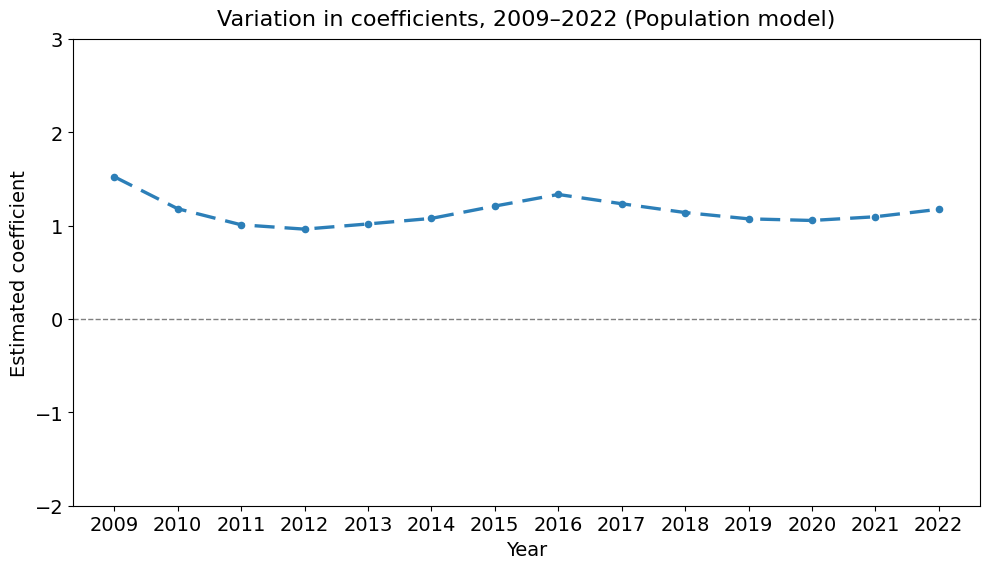

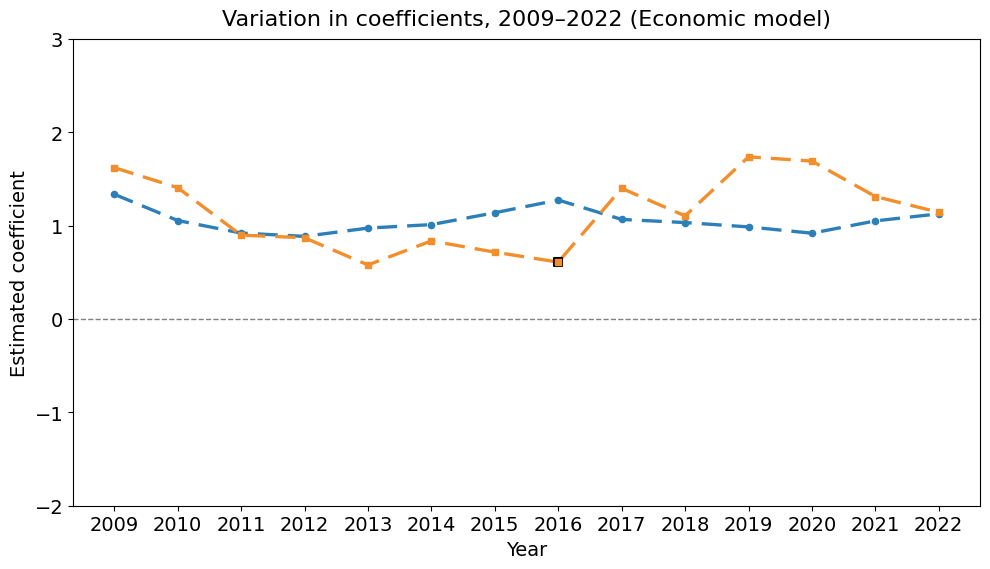

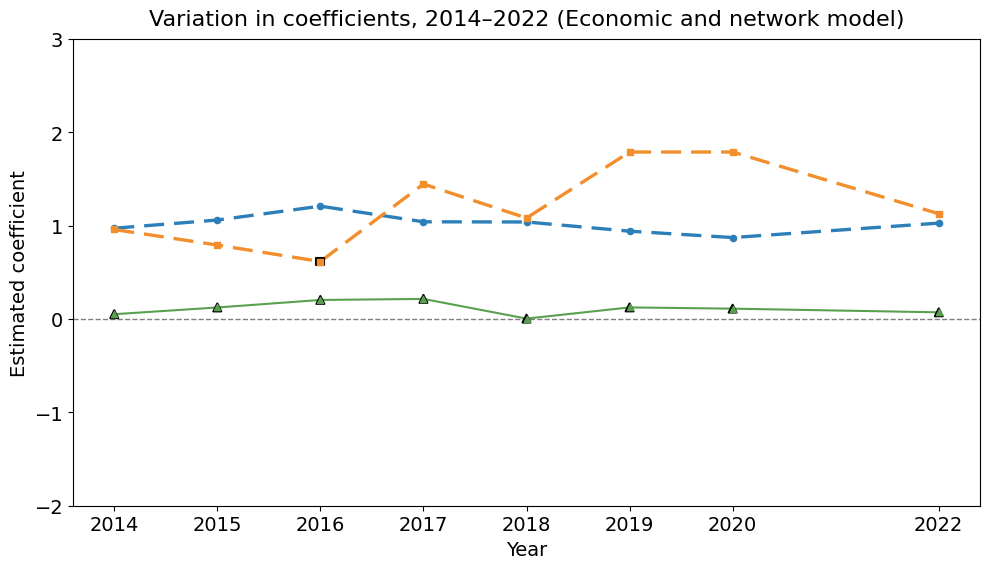

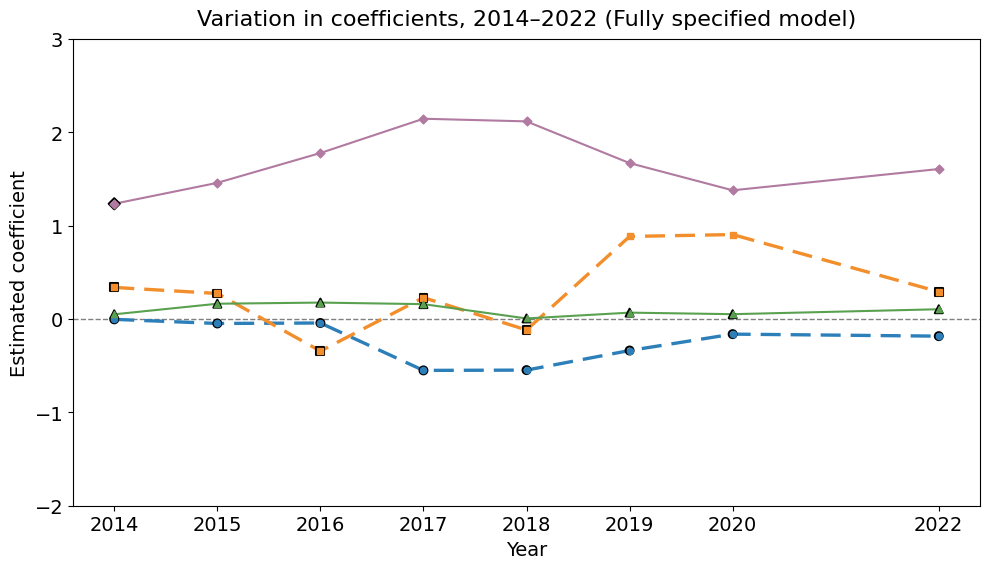


--- Shared Legend ---


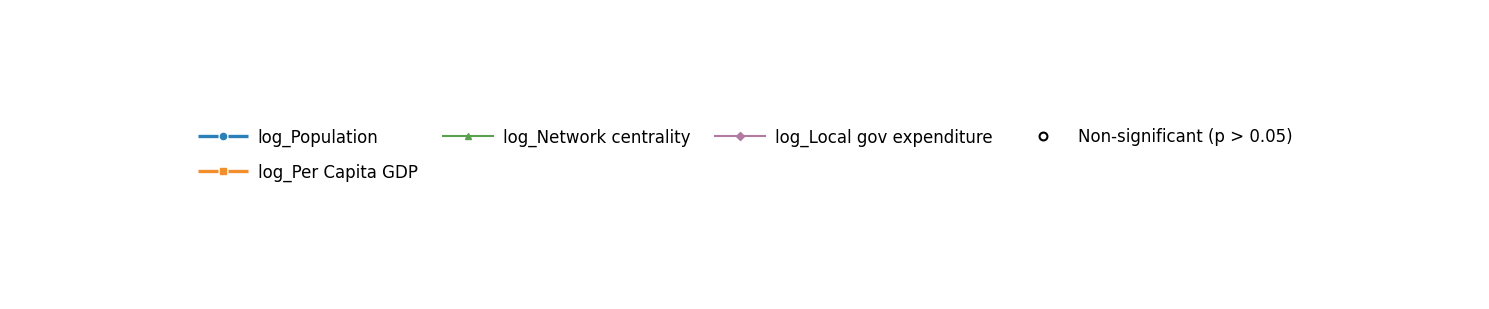

Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option1_no_region_composites_all_years_20260403_011500/visualisations_revised_4models

Processing figures for: Option2_with_region_composites_all_years_20260403_011500


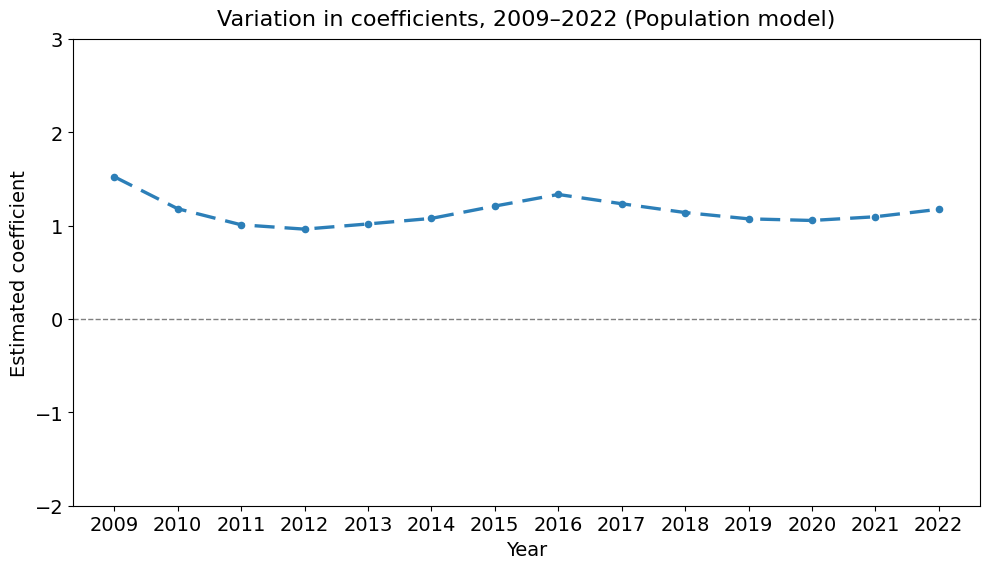

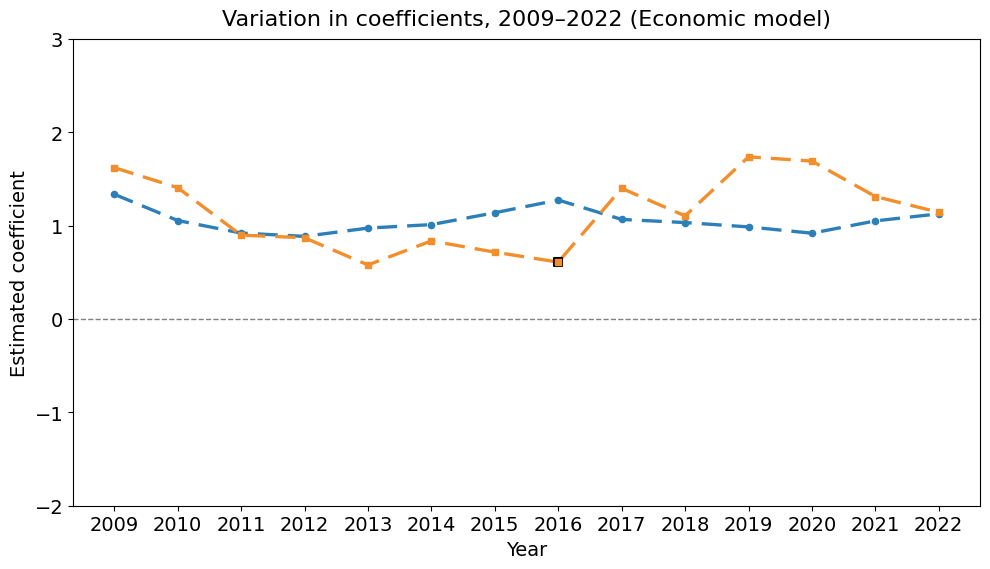

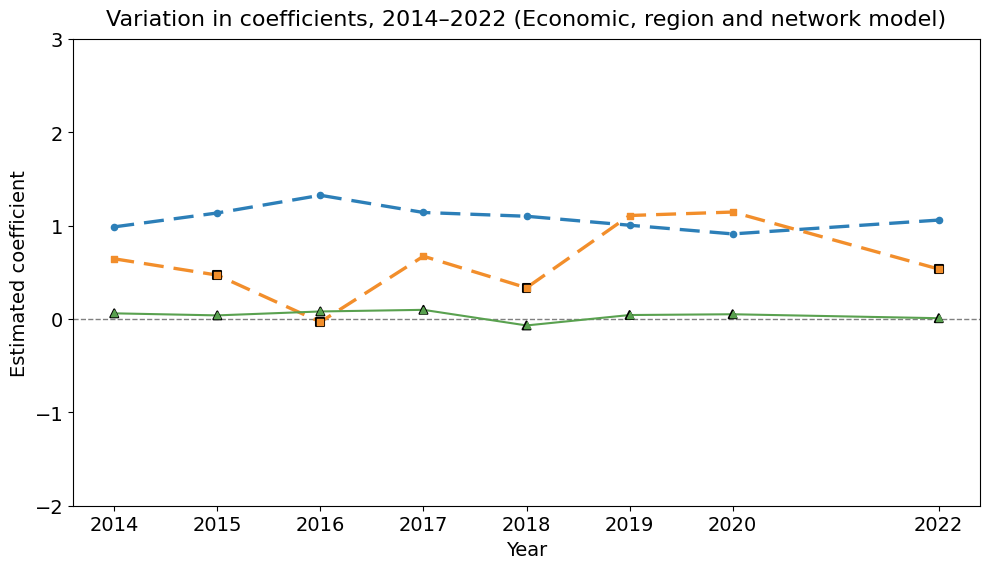

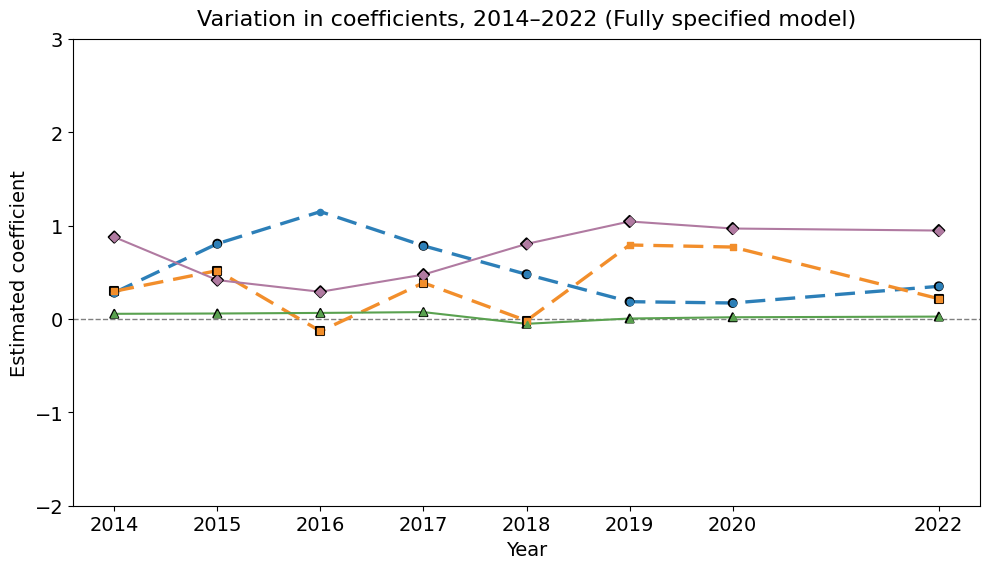


--- Shared Legend ---


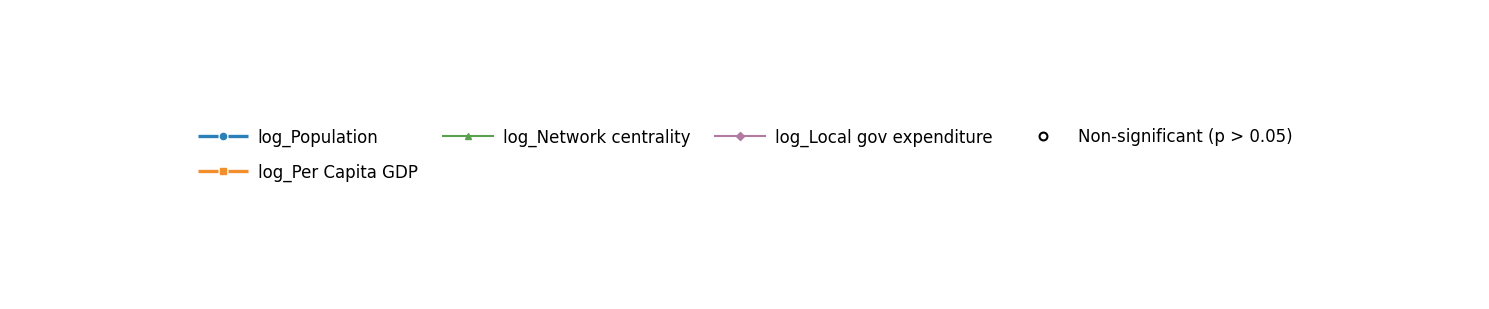

Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option2_with_region_composites_all_years_20260403_011500/visualisations_revised_4models


In [13]:
#@title MVR y axis range -2~+3
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 앞선 셀(1, 2)에서 생성된 폴더 경로 확인
try:
    ROOT_DIRS = [Path(OUT_ROOT_OPT1), Path(OUT_ROOT_OPT2)]
except NameError:
    print("오류: ROOT 폴더 경로 변수가 없습니다. 셀 1과 셀 2를 먼저 실행해주세요.")
    ROOT_DIRS = []

# =========================================================
# global setting
# =========================================================
FIG_W, FIG_H, DPI = 10, 5.8, 600
FONT_FAMILY = "sans-serif"
TITLE_SIZE, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE = 16, 14, 14, 12
LINE_WIDTH, LINE_WIDTH_HIGHLIGHT = 1.5, 2.4
MARKER_SIZE = 20
NS_RING_SCALE, NS_RING_LW = 1.6, 1.5
NS_RING_SIZE = MARKER_SIZE * NS_RING_SCALE
LEG_FIG_W, LEG_FIG_H = 15, 3.2
DASH_HIGHLIGHT = (0, (6, 3))
plt.rcParams["font.family"] = FONT_FAMILY

# =========================================================
# Updated Term names
# =========================================================
TERM_POP   = "log_Population (10000 persons)"
TERM_PCGDP = "log_Per Capita GDP (10,000 yuan)"
TERM_NETC  = "log_network_centrality"
TERM_LOCAL_GOV = "log_local_gov_exp"

def generate_configs(is_option2):
    m3_name = "M3_region_network" if is_option2 else "M3_network"
    m3_title = "Variation in coefficients, 2014–2022 (Economic, region and network model)" if is_option2 else "Variation in coefficients, 2014–2022 (Economic and network model)"

    # y축을 -2부터 4까지, 1 간격으로 고정
    y_range = (-2.0, 3.0, 1.0)

    return [
        {"model_dir_name": "M1_scaling", "fig_prefix": "Fig_S13a", "short_name": "M1", "title": "Variation in coefficients, 2009–2022 (Population model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8")], "highlight_terms": {TERM_POP}, "y_fixed": y_range},
        {"model_dir_name": "M2_econ", "fig_prefix": "Fig_S13b", "short_name": "M2", "title": "Variation in coefficients, 2009–2022 (Economic model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B")], "highlight_terms": {TERM_POP, TERM_PCGDP}, "y_fixed": y_range},
        {"model_dir_name": m3_name, "fig_prefix": "Fig_S13c", "short_name": "M3", "title": m3_title, "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"), (TERM_NETC, "log_Network centrality", "^", "#59A14F")], "highlight_terms": {TERM_POP, TERM_PCGDP}, "y_fixed": y_range},
        {"model_dir_name": "M4_full", "fig_prefix": "Fig_S13d", "short_name": "M4", "title": "Variation in coefficients, 2014–2022 (Fully specified model)", "vars": [
            (TERM_POP, "log_Population", "o", "#2C7FB8"),
            (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"),
            (TERM_NETC, "log_Network centrality", "^", "#59A14F"),
            (TERM_LOCAL_GOV, "log_Local gov expenditure", "D", "#B07AA1")
        ], "highlight_terms": {TERM_POP, TERM_PCGDP}, "y_fixed": y_range},
    ]

CONFIGS_BY_ROOT = {
    root.name: generate_configs("with_region" in root.name) for root in ROOT_DIRS
}

# =========================================================
# 데이터 로드 함수
# =========================================================
def read_model_coefficients(root_dir, model_name, var_specs):
    csv_candidates = list(Path(root_dir).glob("ALL_YEARS_plot_ready_coefficients*.csv"))
    if not csv_candidates:
        return pd.DataFrame()

    df_all = pd.read_csv(csv_candidates[0])
    df_model = df_all[df_all["model"] == model_name].copy()
    if df_model.empty:
        return pd.DataFrame()

    records = []
    for term, label, marker, color in var_specs:
        sub = df_model[df_model["term"] == term].copy()
        for _, row in sub.iterrows():
            coef = pd.to_numeric(row["coef"], errors="coerce")
            se = pd.to_numeric(row["se"], errors="coerce")
            pval = pd.to_numeric(row["p"], errors="coerce")
            if pd.isna(coef): continue

            records.append({
                "Year": int(row["Year"]),
                "term": term,
                "label": label,
                "marker": marker,
                "color": color,
                "coef": coef,
                "se": se,
                "p": pval,
                "significant": False if pd.isna(pval) else (pval <= 0.05),
                "ci_low": row["ci_low"] if "ci_low" in row else (coef - 1.96*se),
                "ci_high": row["ci_high"] if "ci_high" in row else (coef + 1.96*se)
            })

    df_records = pd.DataFrame(records)
    if df_records.empty:
        return df_records
    return df_records.sort_values(["label", "Year"]).reset_index(drop=True)

def plot_one_model(plot_df, var_specs, highlight_terms, title, out_png, out_pdf, out_csv, y_fixed=None):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for term, label, marker, color in var_specs:
        sub = plot_df[plot_df["term"] == term].copy().sort_values("Year")
        if sub.empty: continue
        is_highlight = term in highlight_terms
        ax.plot(sub["Year"].values, sub["coef"].values, linewidth=LINE_WIDTH_HIGHLIGHT if is_highlight else LINE_WIDTH, linestyle=DASH_HIGHLIGHT if is_highlight else "-", dash_capstyle="butt", color=color, zorder=2)
        ns = sub[sub["significant"] == False]
        if not ns.empty: ax.scatter(ns["Year"].values, ns["coef"].values, s=NS_RING_SIZE, marker=marker, facecolors="none", edgecolors="black", linewidths=NS_RING_LW, zorder=3)
        ax.scatter(sub["Year"].values, sub["coef"].values, s=MARKER_SIZE, marker=marker, color=color, edgecolors=color, zorder=4)

    ax.axhline(0, color="gray", linewidth=1.0, linestyle="--", zorder=0)
    ax.set_xticks(sorted(plot_df["Year"].dropna().unique().tolist()))
    ax.set_title(title, fontsize=TITLE_SIZE, pad=10)
    ax.set_xlabel("Year", fontsize=LABEL_SIZE)
    ax.set_ylabel("Estimated coefficient", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

    if y_fixed:
        ax.set_yticks(np.arange(y_fixed[0], y_fixed[1] + 0.001, y_fixed[2]))
        ax.set_ylim(y_fixed[0], y_fixed[1])

    for spine in ax.spines.values(): spine.set_linewidth(0.8)
    plt.tight_layout()
    plot_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight")

    # 코랩 화면에 시각화 출력
    plt.show()
    plt.close(fig)

def build_shared_legend_figure(model_configs, legend_png, legend_pdf):
    unique_items, seen, all_highlights = [], set(), set()
    for cfg in model_configs:
        all_highlights.update(cfg["highlight_terms"])
        for term, label, marker, color in cfg["vars"]:
            if term not in seen:
                seen.add(term)
                unique_items.append((term, label, marker, color))

    handles = [Line2D([0], [0], color=c, linestyle=DASH_HIGHLIGHT if t in all_highlights else "-", linewidth=LINE_WIDTH_HIGHLIGHT if t in all_highlights else LINE_WIDTH, dash_capstyle="butt", marker=m, markersize=np.sqrt(MARKER_SIZE), markerfacecolor=c, markeredgecolor=c, label=l) for t, l, m, c in unique_items]
    handles.append(Line2D([0], [0], color="black", linestyle="None", marker="o", markersize=np.sqrt(NS_RING_SIZE), markerfacecolor="none", markeredgecolor="black", markeredgewidth=NS_RING_LW, label="Non-significant (p > 0.05)"))

    fig_leg, ax_leg = plt.subplots(figsize=(LEG_FIG_W, LEG_FIG_H))
    ax_leg.axis("off")
    ax_leg.legend(handles=handles, loc="center", ncol=4, frameon=False, fontsize=LEGEND_SIZE, handlelength=3.0, handletextpad=0.6, columnspacing=1.5, labelspacing=1.0)
    plt.tight_layout()
    fig_leg.savefig(legend_png, dpi=DPI, bbox_inches="tight", transparent=True)
    fig_leg.savefig(legend_pdf, dpi=DPI, bbox_inches="tight", transparent=True)

    # 코랩 화면에 범례 출력
    plt.show()
    plt.close(fig_leg)

# =========================================================
# Run Graph Plotting
# =========================================================
for ROOT_DIR in ROOT_DIRS:
    if not ROOT_DIR.exists(): continue
    print(f"\n=======================================================")
    print(f"Processing figures for: {ROOT_DIR.name}")
    print(f"=======================================================")
    OUT_DIR = ROOT_DIR / "visualisations_revised_4models"
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for cfg in CONFIGS_BY_ROOT[ROOT_DIR.name]:
        plot_df = read_model_coefficients(ROOT_DIR, cfg["model_dir_name"], cfg["vars"])
        if plot_df.empty:
            print(f"Warning: No valid data found for {cfg['model_dir_name']}. Skipping plot.")
            continue

        plot_one_model(plot_df, cfg["vars"], cfg["highlight_terms"], cfg["title"],
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend_upto3.png",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend_upto3.pdf",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend_upto3.csv",
                       cfg.get("y_fixed"))

    print(f"\n--- Shared Legend ---")
    build_shared_legend_figure(CONFIGS_BY_ROOT[ROOT_DIR.name], OUT_DIR / "Fig_S13_shared_legend.png", OUT_DIR / "Fig_S13_shared_legend.pdf")
    print(f"Figures exported successfully to {OUT_DIR}")


Processing figures for: Option1_no_region_composites_all_years_20260403_011500


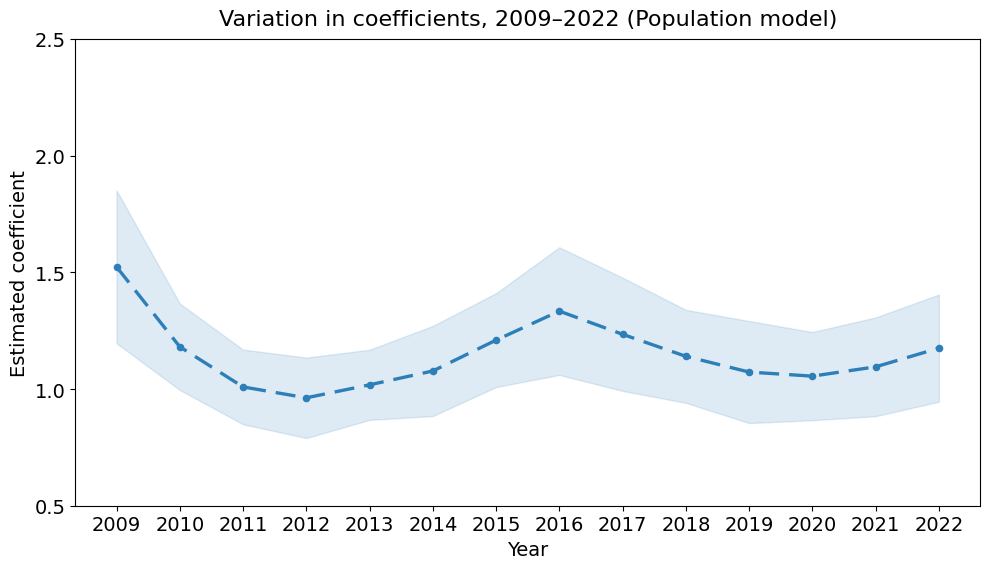

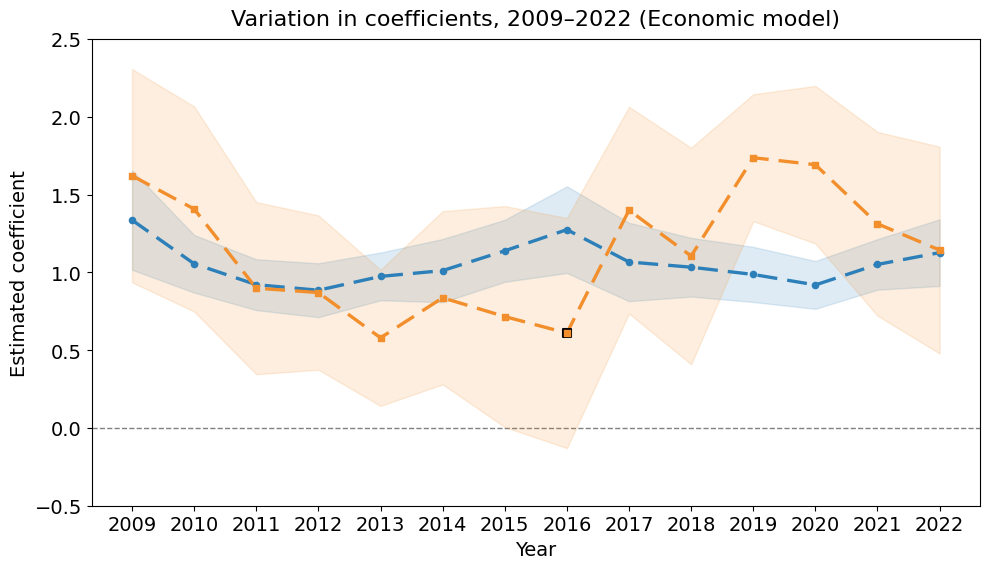

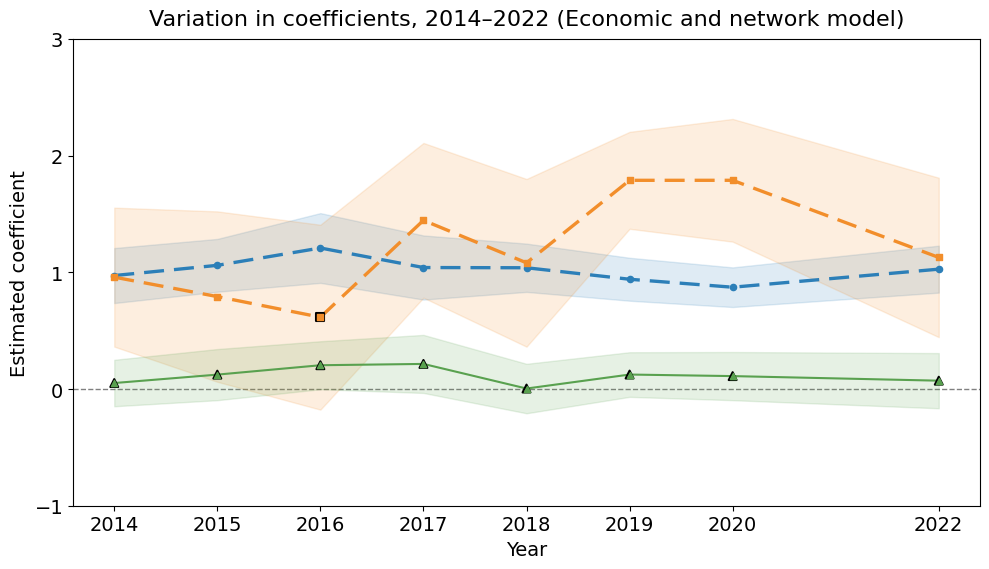

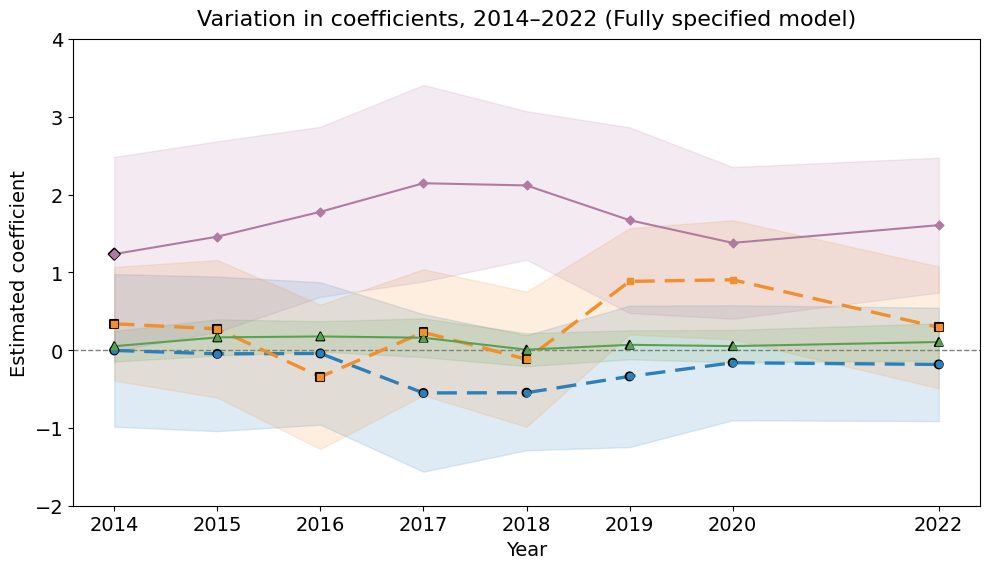


--- Shared Legend ---


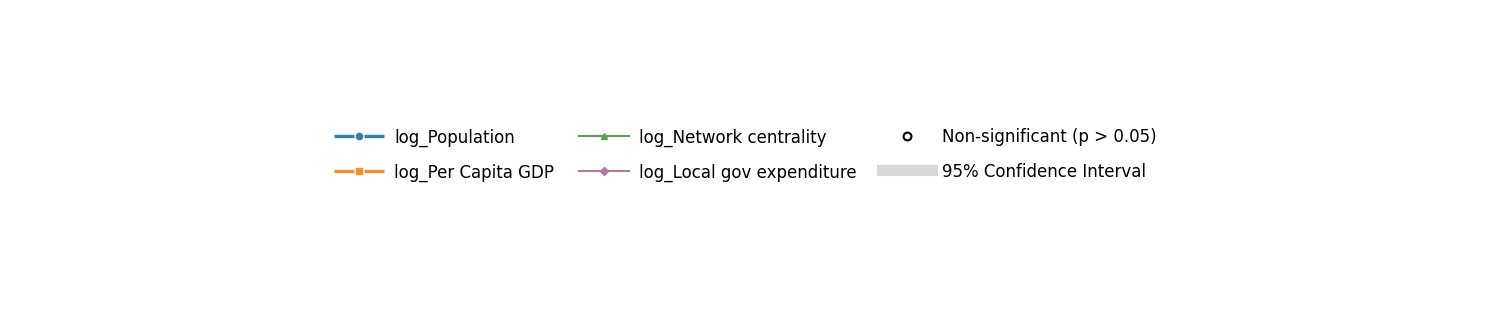

Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option1_no_region_composites_all_years_20260403_011500/visualisations_revised_4models_with_band_auto_y

Processing figures for: Option2_with_region_composites_all_years_20260403_011500


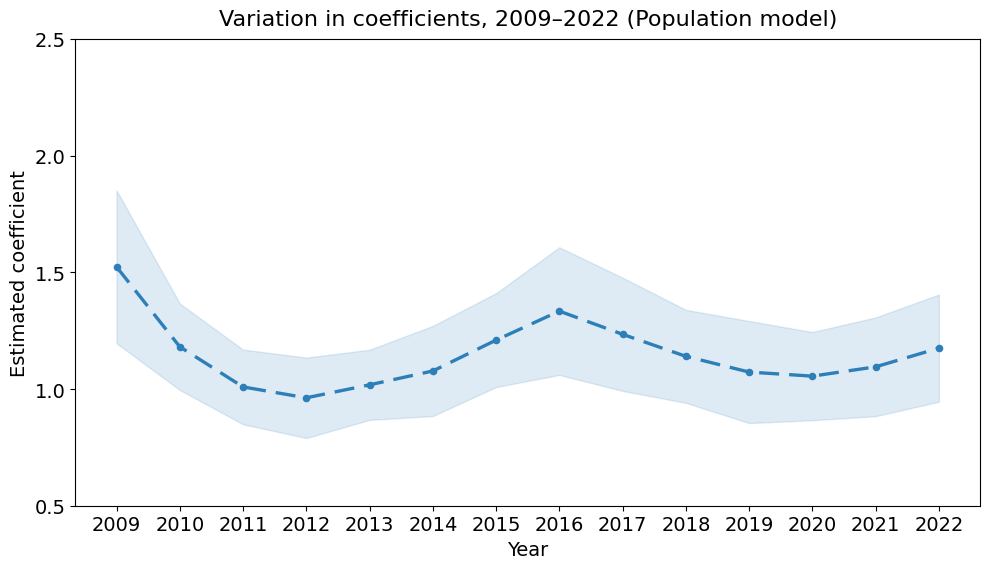

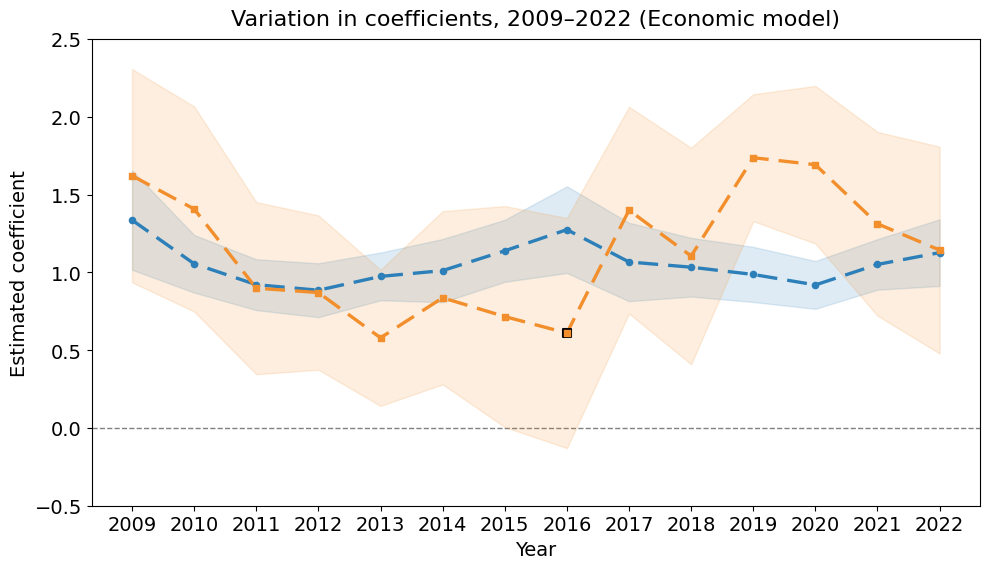

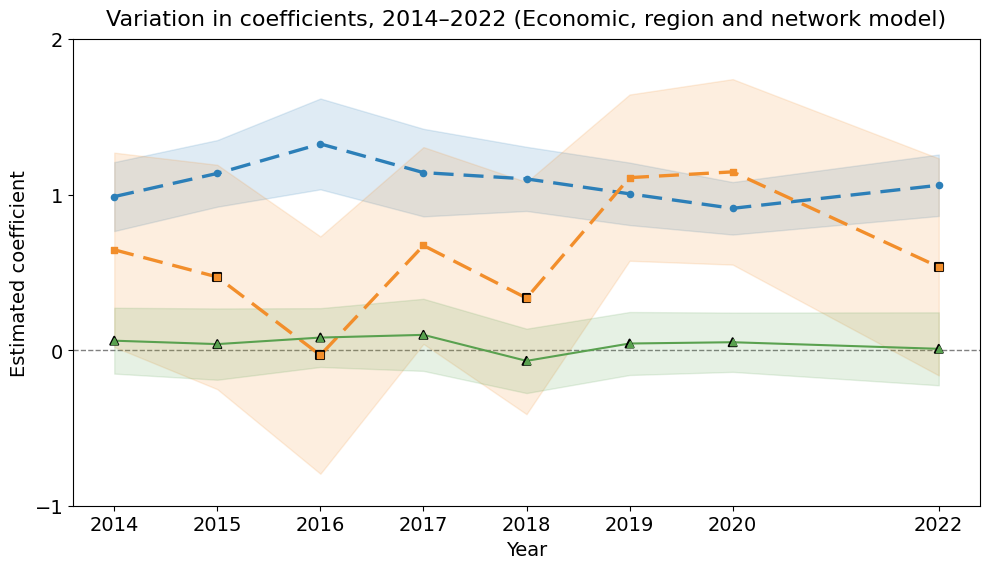

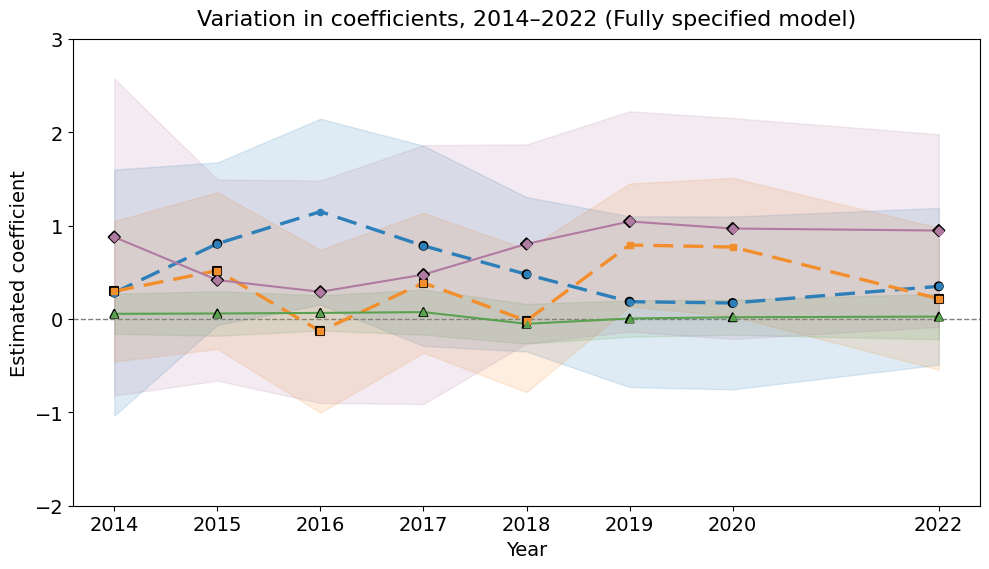


--- Shared Legend ---


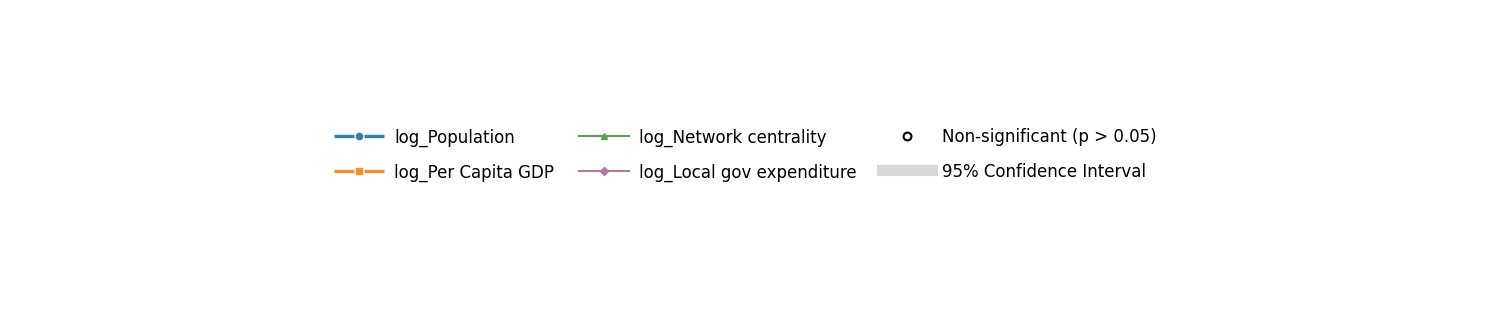

Figures exported successfully to /content/drive/MyDrive/George Land Tax/Option2_with_region_composites_all_years_20260403_011500/visualisations_revised_4models_with_band_auto_y


In [18]:
#@title MVR figs with confidence bands
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 앞선 셀(1, 2)에서 생성된 폴더 경로 확인
try:
    ROOT_DIRS = [Path(OUT_ROOT_OPT1), Path(OUT_ROOT_OPT2)]
except NameError:
    print("오류: ROOT 폴더 경로 변수가 없습니다. 셀 1과 셀 2를 먼저 실행해주세요.")
    ROOT_DIRS = []

# =========================================================
# global setting
# =========================================================
FIG_W, FIG_H, DPI = 10, 5.8, 600
FONT_FAMILY = "sans-serif"
TITLE_SIZE, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE = 16, 14, 14, 12
LINE_WIDTH, LINE_WIDTH_HIGHLIGHT = 1.5, 2.4
MARKER_SIZE = 20
NS_RING_SCALE, NS_RING_LW = 1.6, 1.5
NS_RING_SIZE = MARKER_SIZE * NS_RING_SCALE
LEG_FIG_W, LEG_FIG_H = 15, 3.2
DASH_HIGHLIGHT = (0, (6, 3))
plt.rcParams["font.family"] = FONT_FAMILY

# =========================================================
# Updated Term names
# =========================================================
TERM_POP   = "log_Population (10000 persons)"
TERM_PCGDP = "log_Per Capita GDP (10,000 yuan)"
TERM_NETC  = "log_network_centrality"
TERM_LOCAL_GOV = "log_local_gov_exp"

def generate_configs(is_option2):
    m3_name = "M3_region_network" if is_option2 else "M3_network"
    m3_title = "Variation in coefficients, 2014–2022 (Economic, region and network model)" if is_option2 else "Variation in coefficients, 2014–2022 (Economic and network model)"

    # y축 고정 설정(y_fixed) 제거 -> Auto scaling 적용
    return [
        {"model_dir_name": "M1_scaling", "fig_prefix": "Fig_S13a", "short_name": "M1", "title": "Variation in coefficients, 2009–2022 (Population model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8")], "highlight_terms": {TERM_POP}},
        {"model_dir_name": "M2_econ", "fig_prefix": "Fig_S13b", "short_name": "M2", "title": "Variation in coefficients, 2009–2022 (Economic model)", "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B")], "highlight_terms": {TERM_POP, TERM_PCGDP}},
        {"model_dir_name": m3_name, "fig_prefix": "Fig_S13c", "short_name": "M3", "title": m3_title, "vars": [(TERM_POP, "log_Population", "o", "#2C7FB8"), (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"), (TERM_NETC, "log_Network centrality", "^", "#59A14F")], "highlight_terms": {TERM_POP, TERM_PCGDP}},
        {"model_dir_name": "M4_full", "fig_prefix": "Fig_S13d", "short_name": "M4", "title": "Variation in coefficients, 2014–2022 (Fully specified model)", "vars": [
            (TERM_POP, "log_Population", "o", "#2C7FB8"),
            (TERM_PCGDP, "log_Per Capita GDP", "s", "#F28E2B"),
            (TERM_NETC, "log_Network centrality", "^", "#59A14F"),
            (TERM_LOCAL_GOV, "log_Local gov expenditure", "D", "#B07AA1")
        ], "highlight_terms": {TERM_POP, TERM_PCGDP}},
    ]

CONFIGS_BY_ROOT = {
    root.name: generate_configs("with_region" in root.name) for root in ROOT_DIRS
}

# =========================================================
# 데이터 로드 함수
# =========================================================
def read_model_coefficients(root_dir, model_name, var_specs):
    csv_candidates = list(Path(root_dir).glob("ALL_YEARS_plot_ready_coefficients*.csv"))
    if not csv_candidates:
        return pd.DataFrame()

    df_all = pd.read_csv(csv_candidates[0])
    df_model = df_all[df_all["model"] == model_name].copy()
    if df_model.empty:
        return pd.DataFrame()

    records = []
    for term, label, marker, color in var_specs:
        sub = df_model[df_model["term"] == term].copy()
        for _, row in sub.iterrows():
            coef = pd.to_numeric(row["coef"], errors="coerce")
            se = pd.to_numeric(row["se"], errors="coerce")
            pval = pd.to_numeric(row["p"], errors="coerce")
            if pd.isna(coef): continue

            # ci_low, ci_high 근사치(1.96) 계산
            records.append({
                "Year": int(row["Year"]),
                "term": term,
                "label": label,
                "marker": marker,
                "color": color,
                "coef": coef,
                "se": se,
                "p": pval,
                "significant": False if pd.isna(pval) else (pval <= 0.05),
                "ci_low": row["ci_low"] if "ci_low" in row else (coef - 1.96*se),
                "ci_high": row["ci_high"] if "ci_high" in row else (coef + 1.96*se)
            })

    df_records = pd.DataFrame(records)
    if df_records.empty:
        return df_records
    return df_records.sort_values(["label", "Year"]).reset_index(drop=True)

def choose_y_step(y_min, y_max):
    span = y_max - y_min
    if span <= 1.0: return 0.2, 0.05
    elif span <= 2.5: return 0.5, 0.15
    elif span <= 5.0: return 1.0, 0.2
    return 2.0, 0.5

def plot_one_model(plot_df, var_specs, highlight_terms, title, out_png, out_pdf, out_csv, y_fixed=None):
    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    for term, label, marker, color in var_specs:
        sub = plot_df[plot_df["term"] == term].copy().sort_values("Year")
        if sub.empty: continue
        is_highlight = term in highlight_terms

        # 1. 95% 신뢰 구간 밴드(Confidence Band) 추가
        ax.fill_between(sub["Year"].values, sub["ci_low"].values, sub["ci_high"].values, color=color, alpha=0.15, zorder=1)

        # 2. 계수 선 연결
        ax.plot(sub["Year"].values, sub["coef"].values, linewidth=LINE_WIDTH_HIGHLIGHT if is_highlight else LINE_WIDTH, linestyle=DASH_HIGHLIGHT if is_highlight else "-", dash_capstyle="butt", color=color, zorder=2)
        # 선을 완전히 없애고 독립된 점과 밴드만 표시
        #ax.plot(sub["Year"].values, sub["coef"].values, linestyle="None", color=color, zorder=2)
        # 절충안 (연결성은 주되, 아주 얇은 점선으로 처리하여 독립성 강조)
        #ax.plot(sub["Year"].values, sub["coef"].values, linewidth=0.8, linestyle=":", color=color, zorder=2)

        # 3. 비유의미 마커 (빈 원)
        ns = sub[sub["significant"] == False]
        if not ns.empty:
            ax.scatter(ns["Year"].values, ns["coef"].values, s=NS_RING_SIZE, marker=marker, facecolors="none", edgecolors="black", linewidths=NS_RING_LW, zorder=3)

        # 4. 전체 마커
        ax.scatter(sub["Year"].values, sub["coef"].values, s=MARKER_SIZE, marker=marker, color=color, edgecolors=color, zorder=4)

    ax.axhline(0, color="gray", linewidth=1.0, linestyle="--", zorder=0)
    ax.set_xticks(sorted(plot_df["Year"].dropna().unique().tolist()))
    ax.set_title(title, fontsize=TITLE_SIZE, pad=10)
    ax.set_xlabel("Year", fontsize=LABEL_SIZE)
    ax.set_ylabel("Estimated coefficient", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)

    if y_fixed:
        ax.set_yticks(np.arange(y_fixed[0], y_fixed[1] + 0.001, y_fixed[2]))
        ax.set_ylim(y_fixed[0], y_fixed[1])
    else:
        # 신뢰구간 밴드까지 포함하여 y축 최소/최대값 자동 계산
        y_min = plot_df["ci_low"].min()
        y_max = plot_df["ci_high"].max()
        step, buffer = choose_y_step(y_min, y_max)

        tick_start = np.floor((y_min - buffer) / step) * step
        tick_end = np.ceil((y_max + buffer) / step) * step
        ax.set_yticks(np.arange(tick_start, tick_end + 0.001, step))
        ax.set_ylim(tick_start, tick_end)

    for spine in ax.spines.values(): spine.set_linewidth(0.8)
    plt.tight_layout()
    plot_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
    fig.savefig(out_png, dpi=DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=DPI, bbox_inches="tight")

    # 코랩 화면에 시각화 출력
    plt.show()
    plt.close(fig)

def build_shared_legend_figure(model_configs, legend_png, legend_pdf):
    unique_items, seen, all_highlights = [], set(), set()
    for cfg in model_configs:
        all_highlights.update(cfg["highlight_terms"])
        for term, label, marker, color in cfg["vars"]:
            if term not in seen:
                seen.add(term)
                unique_items.append((term, label, marker, color))

    handles = [Line2D([0], [0], color=c, linestyle=DASH_HIGHLIGHT if t in all_highlights else "-", linewidth=LINE_WIDTH_HIGHLIGHT if t in all_highlights else LINE_WIDTH, dash_capstyle="butt", marker=m, markersize=np.sqrt(MARKER_SIZE), markerfacecolor=c, markeredgecolor=c, label=l) for t, l, m, c in unique_items]
    handles.append(Line2D([0], [0], color="black", linestyle="None", marker="o", markersize=np.sqrt(NS_RING_SIZE), markerfacecolor="none", markeredgecolor="black", markeredgewidth=NS_RING_LW, label="Non-significant (p > 0.05)"))
    handles.append(Line2D([0], [0], color="gray", alpha=0.3, linewidth=8, label="95% Confidence Interval"))

    fig_leg, ax_leg = plt.subplots(figsize=(LEG_FIG_W, LEG_FIG_H))
    ax_leg.axis("off")
    ax_leg.legend(handles=handles, loc="center", ncol=3, frameon=False, fontsize=LEGEND_SIZE, handlelength=3.0, handletextpad=0.6, columnspacing=1.5, labelspacing=1.0)
    plt.tight_layout()
    fig_leg.savefig(legend_png, dpi=DPI, bbox_inches="tight", transparent=True)
    fig_leg.savefig(legend_pdf, dpi=DPI, bbox_inches="tight", transparent=True)

    # 코랩 화면에 범례 출력
    plt.show()
    plt.close(fig_leg)

# =========================================================
# Run Graph Plotting
# =========================================================
for ROOT_DIR in ROOT_DIRS:
    if not ROOT_DIR.exists(): continue
    print(f"\n=======================================================")
    print(f"Processing figures for: {ROOT_DIR.name}")
    print(f"=======================================================")
    OUT_DIR = ROOT_DIR / "visualisations_revised_4models_with_band_auto_y"
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    for cfg in CONFIGS_BY_ROOT[ROOT_DIR.name]:
        plot_df = read_model_coefficients(ROOT_DIR, cfg["model_dir_name"], cfg["vars"])
        if plot_df.empty:
            print(f"Warning: No valid data found for {cfg['model_dir_name']}. Skipping plot.")
            continue

        plot_one_model(plot_df, cfg["vars"], cfg["highlight_terms"], cfg["title"],
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.png",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.pdf",
                       OUT_DIR / f"{cfg['fig_prefix']}_{cfg['short_name']}_coefficients_no_legend.csv",
                       cfg.get("y_fixed"))

    print(f"\n--- Shared Legend ---")
    build_shared_legend_figure(CONFIGS_BY_ROOT[ROOT_DIR.name], OUT_DIR / "Fig_S13_shared_legend.png", OUT_DIR / "Fig_S13_shared_legend.pdf")
    print(f"Figures exported successfully to {OUT_DIR}")

In [19]:
#@title Actually Stabilize?
import pandas as pd
from pathlib import Path

# 앞서 생성한 Option 2 폴더 경로 (환경에 맞게 수정 필요 시 수정)
try:
    OUT_DIR = Path(OUT_ROOT_OPT2)
except NameError:
    # 세션이 초기화되었다면 직접 경로를 입력하세요.
    OUT_DIR = Path("/content/drive/MyDrive/George Land Tax/Option2_with_region_composites_all_years_...") # 생성된 폴더명에 맞춰 수정

csv_files = list(OUT_DIR.glob("ALL_YEARS_plot_ready_coefficients*.csv"))

if not csv_files:
    print("CSV 파일을 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    df_all = pd.read_csv(csv_files[0])

    # 인구 변수 및 2014년 이후 데이터만 필터링
    term_pop = "log_Population (10000 persons)"
    df_pop = df_all[(df_all["term"] == term_pop) & (df_all["Year"] >= 2014)].copy()

    # 모형별 통계량 계산
    stats = []
    for model in ["M1_scaling", "M2_econ", "M3_region_network", "M4_full"]:
        sub = df_pop[df_pop["model"] == model]
        if sub.empty: continue

        coefs = sub["coef"]
        stats.append({
            "Model": model,
            "Mean_Coef": coefs.mean(),
            "Std_Dev (안정성)": coefs.std(),
            "Range (Max-Min)": coefs.max() - coefs.min(),
            "Non-significant Years": len(sub[sub["p"] > 0.05])
        })

    stats_df = pd.DataFrame(stats)
    print("=== 2014~2022년 인구(Population) 계수 변동성 분석 ===")
    display(stats_df)

=== 2014~2022년 인구(Population) 계수 변동성 분석 ===


,Model,Mean_Coef,Std_Dev (안정성),Range (Max-Min),Non-significant Years
0,M1_scaling,1.154762,0.092351,0.278606,0
1,M2_econ,1.067183,0.102797,0.355238,0
2,M3_region_network,1.082892,0.125666,0.413852,0
3,M4_full,0.525914,0.352270,0.978449,7


# Final Path Analysis - with same fonts (for consistency with MVR model figure)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전처리 완료. 최종 분석 데이터 개수: 1378

=== Model 1 Results ===
                  lval  op                 rval  Estimate  Std. Err  \
0  log_per_capita_GRDP   ~              log_pop  0.112554  0.013908   
1              log_TLV   ~              log_pop  1.063836  0.044534   
2              log_TLV   ~  log_per_capita_GRDP  1.162599  0.084277   
3  log_per_capita_GRDP  ~~  log_per_capita_GRDP  0.219338  0.008356   
4              log_TLV  ~~              log_TLV  2.146769  0.081785   

     z-value       p-value  
0   8.092497  6.661338e-16  
1  23.888010  0.000000e+00  
2  13.794910  0.000000e+00  
3  26.248809  0.000000e+00  
4  26.248809  0.000000e+00  


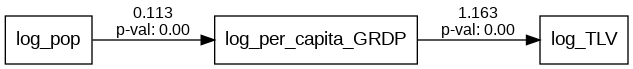


=== Model 2 Results ===
                     lval  op                    rval  Estimate  Std. Err  \
0     log_per_capita_GRDP   ~                 log_pop  0.112553  0.013909   
1  log_network_centrality   ~                 log_pop  0.246374  0.024253   
2                 log_TLV   ~                 log_pop  1.036181  0.046033   
3                 log_TLV   ~     log_per_capita_GRDP  1.192795  0.084153   
4                 log_TLV   ~  log_network_centrality  0.101430  0.048263   
5  log_network_centrality  ~~  log_network_centrality  0.666925  0.025408   
6     log_per_capita_GRDP  ~~     log_per_capita_GRDP  0.219366  0.008357   
7                 log_TLV  ~~                 log_TLV  2.140689  0.081554   

     z-value       p-value  
0   8.091944  6.661338e-16  
1  10.158657  0.000000e+00  
2  22.509367  0.000000e+00  
3  14.174199  0.000000e+00  
4   2.101613  3.558721e-02  
5  26.248809  0.000000e+00  
6  26.248809  0.000000e+00  
7  26.248809  0.000000e+00  


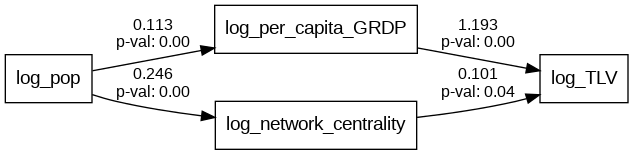


=== Model 3 Results ===
                      lval  op                    rval  Estimate  Std. Err  \
0      log_per_capita_GRDP   ~                 log_pop  0.112605  0.013908   
1   log_network_centrality   ~                 log_pop  0.246299  0.024250   
2        log_local_gov_exp   ~                 log_pop  0.895606  0.011239   
3                  log_TLV   ~                 log_pop -0.181591  0.099989   
4                  log_TLV   ~     log_per_capita_GRDP  0.381641  0.080907   
5                  log_TLV   ~  log_network_centrality  0.102888  0.046401   
6                  log_TLV   ~       log_local_gov_exp  1.461045  0.100114   
7        log_local_gov_exp  ~~       log_local_gov_exp  0.143232  0.005457   
8   log_network_centrality  ~~  log_network_centrality  0.666771  0.025402   
9      log_per_capita_GRDP  ~~     log_per_capita_GRDP  0.219312  0.008355   
10                 log_TLV  ~~                 log_TLV  1.978247  0.075365   

      z-value       p-value  
0    8.0

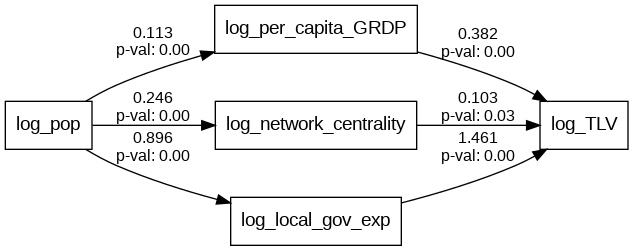

In [12]:
!apt-get -qq install graphviz
!pip install -q semopy

import pandas as pd
import numpy as np
import graphviz
from scipy.stats import zscore
from semopy import Model
import semopy.plot as semplot
from IPython.display import Image, display
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 변수명 공백 제거
df.columns = df.columns.str.strip()

# 2. 1인당 GRDP 산출
df['per_capita_GRDP'] = df['GDP (10,000 yuan)'] / df['Population (10000 persons)']

# 3. 주요 변수 로그 변환 (np.log1p 적용)
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])
df['log_per_capita_GRDP'] = np.log1p(df['per_capita_GRDP'])

# 매개변수 로그 변환
df['log_rail_betw'] = np.log1p(df['rail_node_betweenness_weighted'])
df['log_hw_betw'] = np.log1p(df['hw_node_betweenness_weighted'])
df['log_green_rate'] = np.log1p(df['Green coverage rate of built-up area (%)'])
df['log_park_area'] = np.log1p(df['Park green space area (in hectares)'])
df['log_doctors'] = np.log1p(df['Number of doctors (people)'])
df['log_sci_exp'] = np.log1p(df['Science expenditure (in ten thousand yuan)'])
df['log_edu_exp'] = np.log1p(df['Education expenditure (in ten thousand yuan)'])

# 4. 분석용 데이터셋 결측치 제거
core_vars = [
    'log_pop', 'log_TLV', 'log_per_capita_GRDP',
    'log_rail_betw', 'log_hw_betw', 'log_green_rate', 'log_park_area',
    'log_doctors', 'log_sci_exp', 'log_edu_exp'
]
df_clean = df[core_vars].dropna().copy()

# 5. 통합 지표 생성 (결측치 제거 후 Z-score 산출)
df_clean['z_rail'] = zscore(df_clean['log_rail_betw'])
df_clean['z_hw'] = zscore(df_clean['log_hw_betw'])
df_clean['log_network_centrality'] = (df_clean['z_rail'] + df_clean['z_hw']) / 2

df_clean['z_green_rate'] = zscore(df_clean['log_green_rate'])
df_clean['z_park_area'] = zscore(df_clean['log_park_area'])
df_clean['log_park_infra'] = (df_clean['z_green_rate'] + df_clean['z_park_area']) / 2

# 지방정부 지출(Local Gov Expenditure) 통합 지표 생성
df_clean['z_park_infra'] = zscore(df_clean['log_park_infra'])
df_clean['z_sci'] = zscore(df_clean['log_sci_exp'])
df_clean['z_edu'] = zscore(df_clean['log_edu_exp'])
df_clean['z_doc'] = zscore(df_clean['log_doctors'])
df_clean['log_local_gov_exp'] = (df_clean['z_park_infra'] + df_clean['z_sci'] + df_clean['z_edu'] + df_clean['z_doc']) / 4

print(f"전처리 완료. 최종 분석 데이터 개수: {len(df_clean)}")

# 시각화 처리 함수 (폰트 Helvetica 지정, 직접 경로 숨김 및 좌우 정렬 적용)
def format_sem_plot(model, filename, order_vars=None):
    g = semplot.semplot(model, f"{filename}_temp.png")
    g.graph_attr['rankdir'] = 'LR'

    # 0 안에 점이 생기는 현상을 방지하기 위해 깔끔한 Helvetica 폰트 지정
    g.graph_attr['fontname'] = 'Helvetica'
    g.node_attr['fontname'] = 'Helvetica'
    g.edge_attr['fontname'] = 'Helvetica'

    dot_source = g.source
    new_lines = []
    for line in dot_source.split('\n'):
        if 'log_pop' in line and 'log_TLV' in line and '->' in line:
            continue
        new_lines.append(line)

    new_dot_source = '\n'.join(new_lines)

    if order_vars:
        order_str = " -> ".join(order_vars)
        order_constraint = f"{{rank=same; {order_str} [style=invis];}}"
        new_dot_source = new_dot_source.replace('}', f'  {order_constraint}\n}}')

    g_new = graphviz.Source(new_dot_source)
    g_new.render(filename, format="png", cleanup=True)
    display(Image(f"{filename}.png"))

# ==========================================
# Model 1
# ==========================================
desc1 = """
log_per_capita_GRDP ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP
"""
model1 = Model(desc1)
model1.fit(df_clean)
res1 = model1.inspect()
print("\n=== Model 1 Results ===")
print(res1)
format_sem_plot(model1, "model1_LR_per_capita")

# ==========================================
# Model 2
# ==========================================
desc2 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality
"""
model2 = Model(desc2)
model2.fit(df_clean)
res2 = model2.inspect()
print("\n=== Model 2 Results ===")
print(res2)
order2 = ["log_per_capita_GRDP", "log_network_centrality"]
format_sem_plot(model2, "model2_LR_per_capita", order2)

# ==========================================
# Model 3
# ==========================================
desc3 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_local_gov_exp ~ log_pop

log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality + log_local_gov_exp
"""
model3 = Model(desc3)
model3.fit(df_clean)
res3 = model3.inspect()
print("\n=== Model 3 Results ===")
print(res3)
order3 = ["log_per_capita_GRDP", "log_network_centrality", "log_local_gov_exp"]
format_sem_plot(model3, "model3_LR_per_capita", order3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전처리 완료. 최종 분석 데이터 개수: 1378

=== Model 1 Results ===
                  lval  op                 rval  Estimate  Std. Err  \
0  log_per_capita_GRDP   ~              log_pop  0.112554  0.013908   
1              log_TLV   ~              log_pop  1.063836  0.044534   
2              log_TLV   ~  log_per_capita_GRDP  1.162599  0.084277   
3  log_per_capita_GRDP  ~~  log_per_capita_GRDP  0.219338  0.008356   
4              log_TLV  ~~              log_TLV  2.146769  0.081785   

     z-value       p-value  
0   8.092497  6.661338e-16  
1  23.888010  0.000000e+00  
2  13.794910  0.000000e+00  
3  26.248809  0.000000e+00  
4  26.248809  0.000000e+00  


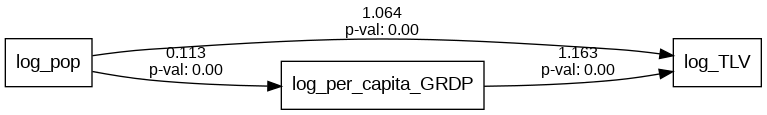


=== Model 2 Results ===
                     lval  op                    rval  Estimate  Std. Err  \
0     log_per_capita_GRDP   ~                 log_pop  0.112553  0.013909   
1  log_network_centrality   ~                 log_pop  0.246374  0.024253   
2                 log_TLV   ~                 log_pop  1.036181  0.046033   
3                 log_TLV   ~     log_per_capita_GRDP  1.192795  0.084153   
4                 log_TLV   ~  log_network_centrality  0.101430  0.048263   
5  log_network_centrality  ~~  log_network_centrality  0.666925  0.025408   
6     log_per_capita_GRDP  ~~     log_per_capita_GRDP  0.219366  0.008357   
7                 log_TLV  ~~                 log_TLV  2.140689  0.081554   

     z-value       p-value  
0   8.091944  6.661338e-16  
1  10.158657  0.000000e+00  
2  22.509367  0.000000e+00  
3  14.174199  0.000000e+00  
4   2.101613  3.558721e-02  
5  26.248809  0.000000e+00  
6  26.248809  0.000000e+00  
7  26.248809  0.000000e+00  


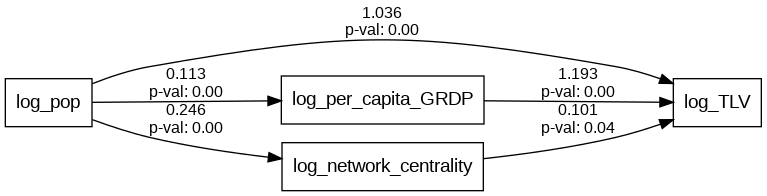


=== Model 3 Results ===
                      lval  op                    rval  Estimate  Std. Err  \
0      log_per_capita_GRDP   ~                 log_pop  0.112605  0.013908   
1   log_network_centrality   ~                 log_pop  0.246299  0.024250   
2        log_local_gov_exp   ~                 log_pop  0.895606  0.011239   
3                  log_TLV   ~                 log_pop -0.181591  0.099989   
4                  log_TLV   ~     log_per_capita_GRDP  0.381641  0.080907   
5                  log_TLV   ~  log_network_centrality  0.102888  0.046401   
6                  log_TLV   ~       log_local_gov_exp  1.461045  0.100114   
7        log_local_gov_exp  ~~       log_local_gov_exp  0.143232  0.005457   
8   log_network_centrality  ~~  log_network_centrality  0.666771  0.025402   
9      log_per_capita_GRDP  ~~     log_per_capita_GRDP  0.219312  0.008355   
10                 log_TLV  ~~                 log_TLV  1.978247  0.075365   

      z-value       p-value  
0    8.0

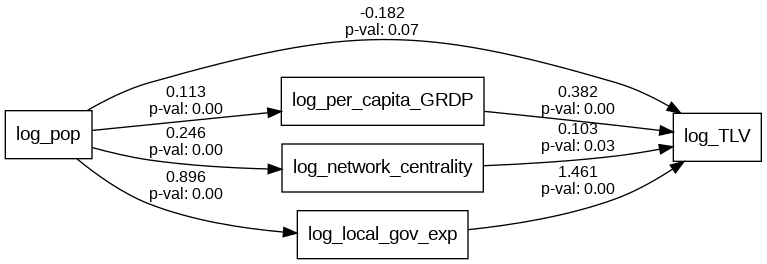

In [24]:
!apt-get -qq install graphviz
!pip install -q semopy

import pandas as pd
import numpy as np
import graphviz
from scipy.stats import zscore
from semopy import Model
import semopy.plot as semplot
from IPython.display import Image, display
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 변수명 공백 제거
df.columns = df.columns.str.strip()

# 2. 1인당 GRDP 산출
df['per_capita_GRDP'] = df['GDP (10,000 yuan)'] / df['Population (10000 persons)']

# 3. 주요 변수 로그 변환 (np.log1p 적용)
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])
df['log_per_capita_GRDP'] = np.log1p(df['per_capita_GRDP'])

# 매개변수 로그 변환
df['log_rail_betw'] = np.log1p(df['rail_node_betweenness_weighted'])
df['log_hw_betw'] = np.log1p(df['hw_node_betweenness_weighted'])
df['log_green_rate'] = np.log1p(df['Green coverage rate of built-up area (%)'])
df['log_park_area'] = np.log1p(df['Park green space area (in hectares)'])
df['log_doctors'] = np.log1p(df['Number of doctors (people)'])
df['log_sci_exp'] = np.log1p(df['Science expenditure (in ten thousand yuan)'])
df['log_edu_exp'] = np.log1p(df['Education expenditure (in ten thousand yuan)'])

# 4. 분석용 데이터셋 결측치 제거
core_vars = [
    'log_pop', 'log_TLV', 'log_per_capita_GRDP',
    'log_rail_betw', 'log_hw_betw', 'log_green_rate', 'log_park_area',
    'log_doctors', 'log_sci_exp', 'log_edu_exp'
]
df_clean = df[core_vars].dropna().copy()

# 5. 통합 지표 생성 (결측치 제거 후 Z-score 산출)
df_clean['z_rail'] = zscore(df_clean['log_rail_betw'])
df_clean['z_hw'] = zscore(df_clean['log_hw_betw'])
df_clean['log_network_centrality'] = (df_clean['z_rail'] + df_clean['z_hw']) / 2

df_clean['z_green_rate'] = zscore(df_clean['log_green_rate'])
df_clean['z_park_area'] = zscore(df_clean['log_park_area'])
df_clean['log_park_infra'] = (df_clean['z_green_rate'] + df_clean['z_park_area']) / 2

# 지방정부 지출(Local Gov Expenditure) 통합 지표 생성
df_clean['z_park_infra'] = zscore(df_clean['log_park_infra'])
df_clean['z_sci'] = zscore(df_clean['log_sci_exp'])
df_clean['z_edu'] = zscore(df_clean['log_edu_exp'])
df_clean['z_doc'] = zscore(df_clean['log_doctors'])
df_clean['log_local_gov_exp'] = (df_clean['z_park_infra'] + df_clean['z_sci'] + df_clean['z_edu'] + df_clean['z_doc']) / 4

print(f"전처리 완료. 최종 분석 데이터 개수: {len(df_clean)}")

# 시각화 처리 함수 (중앙 박스 간격 축소 및 화살표 곡선 최적화)
def format_sem_plot(model, filename, order_vars=None):
    g = semplot.semplot(model, f"{filename}_temp.png")

    g.graph_attr['rankdir'] = 'LR'
    g.graph_attr['splines'] = 'true'  # 과도한 둥글림을 방지하고 깔끔한 곡선 유지

    # 세로 간격(nodesep)은 줄이고, 좌우 간격(ranksep)은 화살표 여유를 위해 적정 확보
    g.graph_attr['nodesep'] = '0.1'
    g.graph_attr['ranksep'] = '1.2'

    # 깔끔한 Helvetica 폰트 지정
    g.graph_attr['fontname'] = 'Helvetica'
    g.node_attr['fontname'] = 'Helvetica'
    g.edge_attr['fontname'] = 'Helvetica'

    dot_source = g.source

    # 매개변수들의 세로 정렬(rank=same) 유지
    if order_vars:
        order_str = " -> ".join(order_vars)
        order_constraint = f"{{rank=same; {order_str} [style=invis];}}"
        dot_source = dot_source.replace('}', f'  {order_constraint}\n}}')

    g_new = graphviz.Source(dot_source)
    g_new.render(filename, format="png", cleanup=True)
    display(Image(f"{filename}.png"))

# ==========================================
# Model 1
# ==========================================
desc1 = """
log_per_capita_GRDP ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP
"""
model1 = Model(desc1)
model1.fit(df_clean)
res1 = model1.inspect()
print("\n=== Model 1 Results ===")
print(res1)
format_sem_plot(model1, "model1_LR_per_capita")

# ==========================================
# Model 2
# ==========================================
desc2 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality
"""
model2 = Model(desc2)
model2.fit(df_clean)
res2 = model2.inspect()
print("\n=== Model 2 Results ===")
print(res2)
order2 = ["log_per_capita_GRDP", "log_network_centrality"]
format_sem_plot(model2, "model2_LR_per_capita", order2)

# ==========================================
# Model 3
# ==========================================
desc3 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_local_gov_exp ~ log_pop

log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality + log_local_gov_exp
"""
model3 = Model(desc3)
model3.fit(df_clean)
res3 = model3.inspect()
print("\n=== Model 3 Results ===")
print(res3)
order3 = ["log_per_capita_GRDP", "log_network_centrality", "log_local_gov_exp"]
format_sem_plot(model3, "model3_LR_per_capita", order3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전처리 완료. 최종 분석 데이터 개수: 1378

=== Model 1 Results ===
                  lval  op                 rval  Estimate  Std. Err  \
0  log_per_capita_GRDP   ~              log_pop  0.112554  0.013908   
1              log_TLV   ~              log_pop  1.063836  0.044534   
2              log_TLV   ~  log_per_capita_GRDP  1.162599  0.084277   
3  log_per_capita_GRDP  ~~  log_per_capita_GRDP  0.219338  0.008356   
4              log_TLV  ~~              log_TLV  2.146769  0.081785   

     z-value       p-value  
0   8.092497  6.661338e-16  
1  23.888010  0.000000e+00  
2  13.794910  0.000000e+00  
3  26.248809  0.000000e+00  
4  26.248809  0.000000e+00  


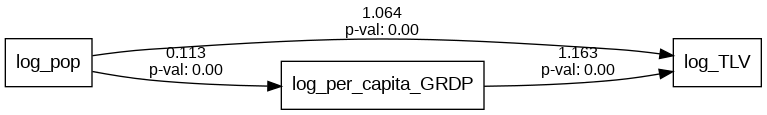


=== Model 2 Results ===
                     lval  op                    rval  Estimate  Std. Err  \
0     log_per_capita_GRDP   ~                 log_pop  0.112553  0.013909   
1  log_network_centrality   ~                 log_pop  0.246374  0.024253   
2                 log_TLV   ~                 log_pop  1.036181  0.046033   
3                 log_TLV   ~     log_per_capita_GRDP  1.192795  0.084153   
4                 log_TLV   ~  log_network_centrality  0.101430  0.048263   
5  log_network_centrality  ~~  log_network_centrality  0.666925  0.025408   
6     log_per_capita_GRDP  ~~     log_per_capita_GRDP  0.219366  0.008357   
7                 log_TLV  ~~                 log_TLV  2.140689  0.081554   

     z-value       p-value  
0   8.091944  6.661338e-16  
1  10.158657  0.000000e+00  
2  22.509367  0.000000e+00  
3  14.174199  0.000000e+00  
4   2.101613  3.558721e-02  
5  26.248809  0.000000e+00  
6  26.248809  0.000000e+00  
7  26.248809  0.000000e+00  


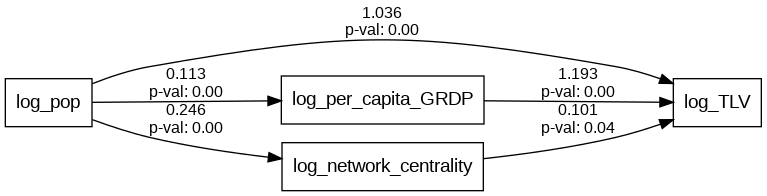


=== Model 3 Results ===
                      lval  op                    rval  Estimate  Std. Err  \
0      log_per_capita_GRDP   ~                 log_pop  0.112605  0.013908   
1   log_network_centrality   ~                 log_pop  0.246299  0.024250   
2        log_local_gov_exp   ~                 log_pop  0.895606  0.011239   
3                  log_TLV   ~                 log_pop -0.181591  0.099989   
4                  log_TLV   ~     log_per_capita_GRDP  0.381641  0.080907   
5                  log_TLV   ~  log_network_centrality  0.102888  0.046401   
6                  log_TLV   ~       log_local_gov_exp  1.461045  0.100114   
7        log_local_gov_exp  ~~       log_local_gov_exp  0.143232  0.005457   
8   log_network_centrality  ~~  log_network_centrality  0.666771  0.025402   
9      log_per_capita_GRDP  ~~     log_per_capita_GRDP  0.219312  0.008355   
10                 log_TLV  ~~                 log_TLV  1.978247  0.075365   

      z-value       p-value  
0    8.0

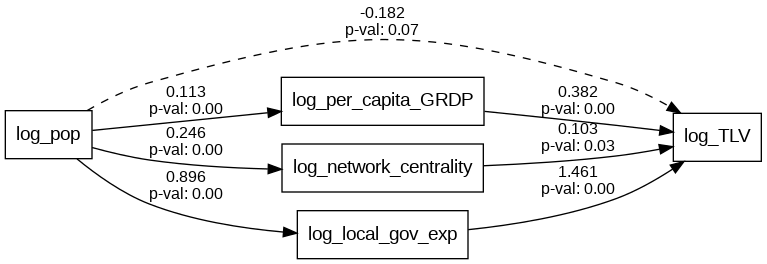

In [26]:
#@title (final) dashed lines for insignificance
!apt-get -qq install graphviz
!pip install -q semopy

import pandas as pd
import numpy as np
import graphviz
from scipy.stats import zscore
from semopy import Model
import semopy.plot as semplot
from IPython.display import Image, display
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 변수명 공백 제거
df.columns = df.columns.str.strip()

# 2. 1인당 GRDP 산출
df['per_capita_GRDP'] = df['GDP (10,000 yuan)'] / df['Population (10000 persons)']

# 3. 주요 변수 로그 변환 (np.log1p 적용)
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])
df['log_per_capita_GRDP'] = np.log1p(df['per_capita_GRDP'])

# 매개변수 로그 변환
df['log_rail_betw'] = np.log1p(df['rail_node_betweenness_weighted'])
df['log_hw_betw'] = np.log1p(df['hw_node_betweenness_weighted'])
df['log_green_rate'] = np.log1p(df['Green coverage rate of built-up area (%)'])
df['log_park_area'] = np.log1p(df['Park green space area (in hectares)'])
df['log_doctors'] = np.log1p(df['Number of doctors (people)'])
df['log_sci_exp'] = np.log1p(df['Science expenditure (in ten thousand yuan)'])
df['log_edu_exp'] = np.log1p(df['Education expenditure (in ten thousand yuan)'])

# 4. 분석용 데이터셋 결측치 제거
core_vars = [
    'log_pop', 'log_TLV', 'log_per_capita_GRDP',
    'log_rail_betw', 'log_hw_betw', 'log_green_rate', 'log_park_area',
    'log_doctors', 'log_sci_exp', 'log_edu_exp'
]
df_clean = df[core_vars].dropna().copy()

# 5. 통합 지표 생성 (결측치 제거 후 Z-score 산출)
df_clean['z_rail'] = zscore(df_clean['log_rail_betw'])
df_clean['z_hw'] = zscore(df_clean['log_hw_betw'])
df_clean['log_network_centrality'] = (df_clean['z_rail'] + df_clean['z_hw']) / 2

df_clean['z_green_rate'] = zscore(df_clean['log_green_rate'])
df_clean['z_park_area'] = zscore(df_clean['log_park_area'])
df_clean['log_park_infra'] = (df_clean['z_green_rate'] + df_clean['z_park_area']) / 2

# 지방정부 지출(Local Gov Expenditure) 통합 지표 생성
df_clean['z_park_infra'] = zscore(df_clean['log_park_infra'])
df_clean['z_sci'] = zscore(df_clean['log_sci_exp'])
df_clean['z_edu'] = zscore(df_clean['log_edu_exp'])
df_clean['z_doc'] = zscore(df_clean['log_doctors'])
df_clean['log_local_gov_exp'] = (df_clean['z_park_infra'] + df_clean['z_sci'] + df_clean['z_edu'] + df_clean['z_doc']) / 4

print(f"전처리 완료. 최종 분석 데이터 개수: {len(df_clean)}")

# 시각화 처리 함수 (p-value 기반 점선 처리 추가)
def format_sem_plot(model, filename, res_df, order_vars=None):
    g = semplot.semplot(model, f"{filename}_temp.png")

    g.graph_attr['rankdir'] = 'LR'
    g.graph_attr['splines'] = 'true'
    g.graph_attr['nodesep'] = '0.1'
    g.graph_attr['ranksep'] = '1.2'

    g.graph_attr['fontname'] = 'Helvetica'
    g.node_attr['fontname'] = 'Helvetica'
    g.edge_attr['fontname'] = 'Helvetica'

    dot_source = g.source
    new_lines = []

    # 모델 결과에서 p-value 정보를 추출하여 딕셔너리로 저장
    paths = res_df[res_df['op'] == '~']
    pval_dict = {(row['rval'], row['lval']): row['p-value'] for _, row in paths.iterrows()}

    for line in dot_source.split('\n'):
        if '->' in line:
            # 해당 라인에 매칭되는 경로(rval -> lval) 찾기
            for (rval, lval), pval in pval_dict.items():
                if f"{rval}" in line and f"{lval}" in line:
                    # p-value가 0.05보다 크면 점선 속성 부여
                    if pd.notna(pval) and pval > 0.05:
                        if ']' in line:
                            line = line.replace(']', ', style="dashed"]')
                        else:
                            line += ' [style="dashed"]'
                    break
        new_lines.append(line)

    new_dot_source = '\n'.join(new_lines)

    if order_vars:
        order_str = " -> ".join(order_vars)
        order_constraint = f"{{rank=same; {order_str} [style=invis];}}"
        new_dot_source = new_dot_source.replace('}', f'  {order_constraint}\n}}')

    g_new = graphviz.Source(new_dot_source)
    g_new.render(filename, format="png", cleanup=True)
    display(Image(f"{filename}.png"))

# ==========================================
# Model 1
# ==========================================
desc1 = """
log_per_capita_GRDP ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP
"""
model1 = Model(desc1)
model1.fit(df_clean)
res1 = model1.inspect()
print("\n=== Model 1 Results ===")
print(res1)
format_sem_plot(model1, "model1_LR_per_capita", res1)

# ==========================================
# Model 2
# ==========================================
desc2 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality
"""
model2 = Model(desc2)
model2.fit(df_clean)
res2 = model2.inspect()
print("\n=== Model 2 Results ===")
print(res2)
order2 = ["log_per_capita_GRDP", "log_network_centrality"]
format_sem_plot(model2, "model2_LR_per_capita", res2, order2)

# ==========================================
# Model 3
# ==========================================
desc3 = """
log_per_capita_GRDP ~ log_pop
log_network_centrality ~ log_pop
log_local_gov_exp ~ log_pop

log_TLV ~ log_pop + log_per_capita_GRDP + log_network_centrality + log_local_gov_exp
"""
model3 = Model(desc3)
model3.fit(df_clean)
res3 = model3.inspect()
print("\n=== Model 3 Results ===")
print(res3)
order3 = ["log_per_capita_GRDP", "log_network_centrality", "log_local_gov_exp"]
format_sem_plot(model3, "model3_LR_per_capita", res3, order3)

# outlier sensitivity 분석

In [27]:
#@title excluding 2 mega cities
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

# 2. Beijing 및 Shanghai 제외 필터링
exclude_cities = ['Beijing', 'Shanghai']
df_filtered = df[~df['City(english)'].isin(exclude_cities)].copy()

print(f"전체 원본 데이터 수: {len(df)}")
print(f"Beijing, Shanghai 제외 후 데이터 수: {len(df_filtered)}")

# 3. 주요 변수 로그 변환 (np.log1p 적용)
df_filtered['log_pop'] = np.log1p(df_filtered['Population (10000 persons)'])
df_filtered['log_TLV'] = np.log1p(df_filtered['Observed TLV (10000 yuan)'])

# 4. 연도별 회귀분석 수행 (log_TLV ~ log_pop)
years = sorted(df_filtered['Year'].dropna().unique())
results = []

for year in years:
    # 해당 연도 데이터 추출 및 결측치 제거
    df_year = df_filtered[df_filtered['Year'] == year][['log_pop', 'log_TLV']].dropna()

    if len(df_year) < 2:
        continue

    # OLS 회귀분석 수행
    model = smf.ols('log_TLV ~ log_pop', data=df_year).fit()

    # 결과 저장
    results.append({
        'Year': int(year),
        'N (도시 수)': len(df_year),
        'Beta (인구 계수)': model.params['log_pop'],
        'Std. Err': model.bse['log_pop'],
        'p-value': model.pvalues['log_pop'],
        'R-squared': model.rsquared
    })

# 5. 결과 출력
results_df = pd.DataFrame(results)
print("\n=== 연도별 인구 스케일링 지수 (Beijing, Shanghai 제외) ===")
display(results_df)

# 필요 시 결과를 CSV로 저장
# results_df.to_csv('/content/drive/MyDrive/George Land Tax/scaling_exponent_without_bj_sh.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전체 원본 데이터 수: 4186
Beijing, Shanghai 제외 후 데이터 수: 4158

=== 연도별 인구 스케일링 지수 (Beijing, Shanghai 제외) ===


,Year,N (도시 수),Beta (인구 계수),Std. Err,p-value,R-squared
0,2009,159,1.588294,0.175345,4.980143e-16,0.343232
1,2010,189,1.169906,0.154554,1.658423e-12,0.234543
2,2011,196,1.001895,0.109642,8.578378e-17,0.300903
3,2012,196,0.966933,0.112508,2.759989e-15,0.275748
4,2013,198,1.027662,0.093530,3.431578e-22,0.381166
5,2014,194,1.060144,0.122320,1.833330e-15,0.281214
6,2015,193,1.206443,0.133993,2.216581e-16,0.297968
7,2016,189,1.350389,0.148842,1.606864e-16,0.305639
8,2017,194,1.222815,0.138903,7.733326e-16,0.287568
9,2018,194,1.135345,0.123432,6.169236e-17,0.305872


In [28]:
#@title excluding 5 cities
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

# 2. Beijing 및 Shanghai 제외 필터링
exclude_cities = ['Beijing', 'Shanghai', 'Chongqing', 'Guangzhou', 'Shenzhen']
df_filtered = df[~df['City(english)'].isin(exclude_cities)].copy()

print(f"전체 원본 데이터 수: {len(df)}")
print(f"Beijing, Shanghai 제외 후 데이터 수: {len(df_filtered)}")

# 3. 주요 변수 로그 변환 (np.log1p 적용)
df_filtered['log_pop'] = np.log1p(df_filtered['Population (10000 persons)'])
df_filtered['log_TLV'] = np.log1p(df_filtered['Observed TLV (10000 yuan)'])

# 4. 연도별 회귀분석 수행 (log_TLV ~ log_pop)
years = sorted(df_filtered['Year'].dropna().unique())
results = []

for year in years:
    # 해당 연도 데이터 추출 및 결측치 제거
    df_year = df_filtered[df_filtered['Year'] == year][['log_pop', 'log_TLV']].dropna()

    if len(df_year) < 2:
        continue

    # OLS 회귀분석 수행
    model = smf.ols('log_TLV ~ log_pop', data=df_year).fit()

    # 결과 저장
    results.append({
        'Year': int(year),
        'N (도시 수)': len(df_year),
        'Beta (인구 계수)': model.params['log_pop'],
        'Std. Err': model.bse['log_pop'],
        'p-value': model.pvalues['log_pop'],
        'R-squared': model.rsquared
    })

# 5. 결과 출력
results_df = pd.DataFrame(results)
print("\n=== Yearly pop scaling exponents (5 cities excluded ===")
display(results_df)

# 필요 시 결과를 CSV로 저장
# results_df.to_csv('/content/drive/MyDrive/George Land Tax/scaling_exponent_without_bj_sh.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전체 원본 데이터 수: 4186
Beijing, Shanghai 제외 후 데이터 수: 4116

=== 연도별 인구 스케일링 지수 (Beijing, Shanghai 제외) ===


,Year,N (도시 수),Beta (인구 계수),Std. Err,p-value,R-squared
0,2009,156,1.585917,0.191014,4.851968e-14,0.309211
1,2010,186,1.182027,0.167394,3.274354e-11,0.213214
2,2011,193,1.024024,0.118528,2.235418e-15,0.280986
3,2012,193,0.961015,0.121345,1.906730e-13,0.247206
4,2013,195,1.051326,0.100590,1.509307e-20,0.361424
5,2014,191,1.051064,0.132321,1.717779e-13,0.250286
6,2015,190,1.203038,0.145617,2.518660e-14,0.266355
7,2016,186,1.394381,0.162246,3.552587e-15,0.286437
8,2017,191,1.288015,0.148729,2.066085e-15,0.284087
9,2018,191,1.165461,0.133560,1.364610e-15,0.287183


In [29]:
#@title all sample exponents trend
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from google.colab import drive

# 1. 구글 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/George Land Tax/Top 2009-2022 Chinese City Panel Data (Urban Districts) 0330.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')

# 변수명 공백 제거
df.columns = df.columns.str.strip()

print(f"전체 원본 데이터 수 (모든 도시 포함): {len(df)}")

# 2. 주요 변수 로그 변환 (np.log1p 적용)
df['log_pop'] = np.log1p(df['Population (10000 persons)'])
df['log_TLV'] = np.log1p(df['Observed TLV (10000 yuan)'])

# 3. 연도별 회귀분석 수행 (log_TLV ~ log_pop)
years = sorted(df['Year'].dropna().unique())
results_full = []

for year in years:
    # 해당 연도 데이터 추출 및 결측치 제거
    df_year = df[df['Year'] == year][['log_pop', 'log_TLV']].dropna()

    if len(df_year) < 2:
        continue

    # OLS 회귀분석 수행
    model = smf.ols('log_TLV ~ log_pop', data=df_year).fit()

    # 결과 저장
    results_full.append({
        'Year': int(year),
        'N (도시 수)': len(df_year),
        'Beta (인구 계수)': model.params['log_pop'],
        'Std. Err': model.bse['log_pop'],
        'p-value': model.pvalues['log_pop'],
        'R-squared': model.rsquared
    })

# 4. 결과 출력
results_full_df = pd.DataFrame(results_full)
print("\n=== 연도별 인구 스케일링 지수 (모든 도시 포함 원본) ===")
display(results_full_df)

# 필요 시 결과를 CSV로 저장
# results_full_df.to_csv('/content/drive/MyDrive/George Land Tax/scaling_exponent_full_data.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
전체 원본 데이터 수 (모든 도시 포함): 4186

=== 연도별 인구 스케일링 지수 (모든 도시 포함 원본) ===


,Year,N (도시 수),Beta (인구 계수),Std. Err,p-value,R-squared
0,2009,161,1.523470,0.164266,1.239918e-16,0.351058
1,2010,191,1.181018,0.143755,3.270816e-14,0.263142
2,2011,198,1.008942,0.102130,6.192843e-19,0.332413
3,2012,198,0.962318,0.104980,6.715798e-17,0.300069
4,2013,200,1.017926,0.087377,3.165952e-24,0.406686
5,2014,196,1.077288,0.114134,1.212434e-17,0.314710
6,2015,195,1.209451,0.125323,3.125368e-18,0.325495
7,2016,191,1.333765,0.138980,5.121543e-18,0.327638
8,2017,196,1.234362,0.130272,9.551507e-18,0.316375
9,2018,196,1.140031,0.115920,8.949143e-19,0.332692
